# Assignment 07 - Deep Architectures, Training Stability, and Evaluation Maturity

### Due: Monday, Mar 16, before class

**NOTE: Due after Spring Break**

Name(s): Chang Min<br>
Course: CSCI 357 - AI and Neural Networks<br>
Section: 01 - 1:00pm<br>
Semester: Spring 2026<br>
Instructor: Prof. King<br>

### References



In [1]:
import sys
import os
import time
from enum import Enum

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Basic configuration
torch.manual_seed(42)
np.random.seed(42)
sns.set_theme(style="whitegrid")

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.10.0+cu128


In [2]:
from IPython.display import HTML, display

# Define CSS styles in a string variable for reuse across cells
css_styles = """
<style>
.todo-box {
    background-color: #fcf8e3;
    color: #000000;
    border-left: 6px solid #f0ad4e;
    padding: 10px;
    margin-bottom: 0;
}

.todo-box h3 {
    margin-top: 0;
}

.note-box {
    background-color: #d1ecf1;
    color: #000000;
    border-left: 6px solid #0c5460;
    padding: 10px;
    margin-bottom: 0;
}

.warning-box {
    background-color: #f8d7da;
    color: #000000;
    border-left: 6px solid #721c24;
    padding: 10px;
    margin-bottom: 0;
}

.section-box {
    background-color: rgb(125, 233, 150);
    color: #000000;
    border-left: 6px solid #155724;
    padding: 10px;
    margin-bottom: 0;
}
</style>
"""

display(HTML(css_styles))

In [3]:

def show_todo(todo_text):
    display(HTML(f"""
    <div class="todo-box">
    <h2>TODO: {todo_text}</h2>
    </div>
    """))

def show_note(note_text):
    display(HTML(f"""
    <div class="note-box">
    <h2>NOTE:</h2>
    <h4>{note_text}</h4>
    </div>
    """))

def show_warning(warning_text):
    display(HTML(f"""
    <div class="warning-box">
    <h2>WARNING:</h2>
    <h3>{warning_text}</h3>
    </div>
    """))

def show_section(section_text = ""):
    display(HTML(f"""
    <div class="section-box">
    <h1>{section_text}</h1>
    </div>
    """))

In [4]:
show_todo("Set Run Configuration")

# **Notebook Run Configuration**

As most of you have already discovered, you will frequently need to re-run your notebooks from scratch. As our models and data become larger and more complex, code cells that execute training can take a lot of time. Thus, once you have finish a cell that needs to train, you might want to just execute a few epochs, or perhaps NO epochs.

* Set the variable `RUN_TRAINING_MODE` below to one of the three enumerations, then write your code to conditionally set the number of epoch to run
* Set `DO_WANDB_LOGGING` to True when you are ready to log your results.

It's up to you to properly use these constants in your code to make it easy to rerun a notebook from scratch.

In [5]:
class RunTrainingMode(Enum):
    NONE = "NONE"
    QUICK = "QUICK"
    FULL = "FULL"

RUN_TRAINING_MODE = RunTrainingMode.FULL
DO_WANDB_LOGGING = True

# **Set up accelerator device**
> This code will create three variables
> * `cpu_device` - the default device all tensors are stored on when not explicity moving over to a GPU
> * `has_accel` - bool - `True` if you have a GPU, `False` otherwise.
> * `accel_device` - your accelerator device if you have a GPU, or set to `cpu_device` if no GPU is present to prevent exceptions if trying to run on a GPU when one is not available.


In [6]:
cpu_device = torch.device("cpu")

# True if *some* accelerator is available (CUDA, MPS, etc.)
has_accel = torch.accelerator.is_available()
print(f"Accelerator available: {has_accel}")

# A torch.device representing the preferred accelerator (if any). If none available, set it to "cpu"
if has_accel:
    accel_device = torch.accelerator.current_accelerator()
    print(f"Preferred accelerator: {accel_device}")
else:
    accel_device = cpu_device
    print("No accelerator available, defaulting to CPU.")

Accelerator available: True
Preferred accelerator: cuda


In [7]:
# Are we running from colab?
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab")
else:
    print("Not running in Google Colab")

Running in Google Colab


In [8]:
show_todo("Set Project Path and Install Packages")

**TODO:** You need to set `project_path` to be the root path of your project. This needs to be done regardless if whether you are running from Colab or not. I included an example that works on my machine when running locally, and setting a Drive path when running from Google Colab.

In [9]:
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Drive mounted successfully!")

    # DONE: Replace this with your Google Drive path to your project root. Below is an example:
    PROJECT_PATH = '/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp'

    # Confirm the project_path exists, raise an error if not
    if not os.path.exists(PROJECT_PATH):
        raise FileNotFoundError(f"Project path NOT FOUND: \"{PROJECT_PATH}\"")
    else:
        print(f"Confirmed: Project path exists at \"{PROJECT_PATH}\"")
else:
    # DONE: Replace this with your project root.
    PROJECT_PATH = '/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp'

print(f"Project path: \"{PROJECT_PATH}\"")
if PROJECT_PATH not in sys.path:
    sys.path.append(PROJECT_PATH)
    sys.path.append(PROJECT_PATH + "/src")

# Ensure that the current working directory is PROJECT_PATH
if os.getcwd() != PROJECT_PATH:
    print(f"Changing working directory to project path: \"{PROJECT_PATH}\"")
    os.chdir(PROJECT_PATH)
else:
    print(f"Already in the correct working directory: \"{PROJECT_PATH}\"")

Mounted at /content/drive
Drive mounted successfully!
Confirmed: Project path exists at "/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp"
Project path: "/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp"
Changing working directory to project path: "/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp"


In [10]:
# Install any packages that are not part of the standard Google Colab environment
if IN_COLAB:
    # Install uv for fast installs (-q for quiet, -U for update)
    !pip install -qU uv
    # Install project dependencies and local code in editable mode,
    !uv pip install -e .
    print("Colab install commands are provided above; uncomment to run them.")
else:
    print("Running locally, assuming project dependencies installed in your local environment.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 111.3 MB/s eta 0:00:0000:0100:01
Using Python 3.12.12 environment at: /usr
Resolved 199 packages in 842ms                                       
Prepared 21 packages in 2.24s                                            
Uninstalled 3 packages in 71ms
Installed 21 packages in 69ms                               
 + asttokens==3.0.1
 + async-lru==2.2.0
 + executing==2.2.1
 - ipython==7.34.0
 + ipython==9.10.0
 + ipython-pygments-lexers==1.1.1
 + jedi==0.19.2
 + json5==0.13.0
 + jupyter==1.1.1
 + jupyter-lsp==2.3.0
 + jupyterlab==4.5.5
 + jupyterlab-server==2.28.0
 + lantern==0.1.0 (from file:///content/drive/My%20Drive/2026%20SS/CSCI357/csci357_2026sp)
 + lightning-utilities==0.15.3
 + pure-eval==0.2.3
 + pydeck==0.9.1
 - scipy==1.16.3
 + scipy==1.13.1
 + stack-data==0.6.3
 + streamlit==1.55.0
 + torchmetrics==1.8.2
 - traitlets==5.7.1
 + traitlets==5.14.3
 + ucimlrepo==0.0.7
Colab install commands are provided above; uncomment to ru

In [11]:
# Once packages are installed, we can kill the kernel to force a restart. Just restart the kernel
if IN_COLAB:
    try:
        import lantern
        print(lantern.__file__)
        print("Success!")
    except Exception as e:
        print("Might need to restart your kernel.")
        # This will force the kernel to restart
        # import os
        # os.kill(os.getpid(), 9)

/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp/src/lantern/__init__.py
Success!


In [12]:
# This cell loads the 'autoreload' extension for IPython/Jupyter, which automatically reloads any modules
# you import whenever their code changes on disk. The first line loads the extension, and the second line
# sets autoreload to mode 2, which reloads all modules (except those excluded by %aimport) before each execution.
# This is especially useful when you're actively developing Python modules in separate files and want
# changes to be picked up immediately without restarting the notebook kernel.
# The 'imp' module is deprecated in Python 3.4 and removed in Python 3.12. Newer IPython/Jupyter versions
# of autoreload should not need it. Removing the install command.
#
# Turn on the "Auto-Updater"
%load_ext autoreload
%autoreload 2

In [13]:
import wandb

In [14]:
show_todo("Set W&B Configuration Variables")

# Set your identity variables for W&B!

Fill in the following variables below to ensure your data is properly logged to Weights & Biases

In [15]:
# DO NOT CHANGE THIS:
entity = "bucknell-university-csci357-2026sp"

# DONE: Fill in your name, user id, and email
user_name = "Chang Min Bark"
user_initials = "CMB"
user_id = "cb073"
user_email = "cb073@bucknell.edu"

In [16]:
show_section()

# Background

Last week you built and trained CNNs using the engine we developed in hw05. A 2-block CNN beat an MLP by ~3 percentage points on FashionMNIST with fewer effective parameters -- proof that inductive bias matters. But our CNN was shallow: just two `[Conv2d -> ReLU -> MaxPool2d]` blocks. What happens when you try to go deeper?

This week we tackle the problems that emerge at depth and the engineering techniques that solve them: **Batch Normalization**, **Residual Connections**, and **Global Average Pooling**. We also graduate from scalar accuracy to **confusion matrices** and learn to handle **class imbalance** -- two challenges you will encounter in every real-world ML project.

## 1. The Depth Problem: Why Deeper Networks Broke

In hw06, we used 2 conv blocks. Intuitively, deeper networks should be more powerful -- more layers mean more capacity to learn complex features. The early layers detect edges, middle layers detect textures and parts, and deep layers detect whole objects. So why not stack 10 or 20 blocks?

The answer lies in how gradients flow during backpropagation. Recall from the chain rule that the gradient of the loss with respect to an early layer's weights is a **product** of all the intermediate gradients:

$$\frac{\partial \mathcal{L}}{\partial W_1} = \frac{\partial \mathcal{L}}{\partial h_L} \cdot \frac{\partial h_L}{\partial h_{L-1}} \cdots \frac{\partial h_2}{\partial h_1} \cdot \frac{\partial h_1}{\partial W_1}$$

If each factor $\frac{\partial h_i}{\partial h_{i-1}}$ has magnitude less than 1 (common with sigmoid or tanh activations, or poorly initialized weights), the product shrinks **exponentially** with depth:

$$\left|\frac{\partial \mathcal{L}}{\partial W_1}\right| \approx c^L \quad \text{where } c < 1$$

With $L = 20$ layers and $c = 0.5$, the gradient reaching the first layer is $0.5^{20} \approx 10^{-6}$ -- essentially zero. The early layers stop learning entirely. This is the **vanishing gradient problem**.

The opposite can also happen: if each factor exceeds 1, gradients **explode** exponentially, causing NaN losses and divergent training. This is the **exploding gradient problem**.

ReLU activations help by providing gradients of exactly 1 for positive inputs (no shrinkage), but they don't fully solve the problem in very deep networks because the *accumulated* effect of many layers still destabilizes training. Two key innovations from 2015-2016 made deep networks trainable: **Batch Normalization** and **Residual Connections**.

In [17]:
show_note("The vanishing gradient problem was the primary reason deep learning stagnated between 1990 and 2012. The breakthroughs that solved it, BatchNorm and ResNets, are why we can now train networks with hundreds of layers.")

## 2. Batch Normalization (BN)

**Batch Normalization** (Ioffe & Szegedy, 2015) is a technique that normalizes the activations within each mini-batch, stabilizing the distribution of inputs to each layer during training.

### The Core Idea

Without normalization, the distribution of each layer's inputs shifts as the parameters of all preceding layers change during training. This phenomenon is called **internal covariate shift**. Each layer must constantly adapt to a moving target, which slows convergence and requires careful initialization and small learning rates.

BatchNorm fixes this by normalizing activations to zero mean and unit variance, then applying a learnable scale and shift:

**Step 1 -- Normalize:** Given a mini-batch of activations $\{x_1, \ldots, x_m\}$ for a particular channel:

$$\mu_B = \frac{1}{m}\sum_{i=1}^{m} x_i \qquad \sigma_B^2 = \frac{1}{m}\sum_{i=1}^{m}(x_i - \mu_B)^2$$

$$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$

where $\epsilon$ is a small constant (e.g., $10^{-5}$) for numerical stability.

**Step 2 -- Scale and shift:** The normalized value is then transformed by **learnable** parameters $\gamma$ (scale) and $\beta$ (shift):

$$y_i = \gamma \hat{x}_i + \beta$$

Why learnable parameters? If the network *needs* the activations to be non-zero-mean or non-unit-variance for a particular layer, $\gamma$ and $\beta$ let it undo the normalization. In the extreme case where $\gamma = \sigma_B$ and $\beta = \mu_B$, the transform is the identity -- BatchNorm can learn to do nothing if that is optimal.

### Training vs. Inference: A Critical Distinction

During **training**, BatchNorm uses the statistics ($\mu_B$, $\sigma_B^2$) computed from the current mini-batch.

During **inference**, there is no "batch" -- you might be predicting on a single image. So BatchNorm uses **running averages** of $\mu$ and $\sigma^2$ that were accumulated during training (exponential moving average).

This is why `model.train()` and `model.eval()` matter critically now:
* `model.train()` tells BatchNorm layers to use batch statistics and update the running averages.
* `model.eval()` tells BatchNorm layers to use the stored running averages.

In [18]:
show_warning("If you forget model.eval() before validation, BatchNorm will use mini-batch statistics from the validation set instead of the stable running averages from training. This silently corrupts your metrics and can make validation loss appear noisier than it actually is. Always call model.eval() before validation and model.train() before training.")

### Where BatchNorm Goes in the CNN Motif

The updated block pattern becomes:

```
[Conv2d -> BatchNorm2d -> ReLU -> MaxPool2d] x N  ->  Flatten  ->  Linear -> ...
├──────── feature extractor ────────────────┤         ├─── classifier head ──┤
```

BatchNorm is inserted **after** the convolution and **before** the activation function. This is the standard placement.

### Parameter Cost

For a conv layer with $C$ output channels, `BatchNorm2d(C)` adds exactly $2C$ learnable parameters ($\gamma$ and $\beta$, one per channel) plus $2C$ non-learnable running statistics. For 64 channels, that is 128 extra learnable parameters -- negligible compared to the conv layer itself.

### Engineering Benefits

BatchNorm provides several practical benefits:
1. **Faster convergence**: You can use larger learning rates without divergence.
2. **Reduces sensitivity to initialization**: Less need for careful weight initialization schemes.
3. **Slight regularization effect**: The noise introduced by batch statistics acts as a mild regularizer, sometimes reducing the need for dropout in the conv layers.

> **Note:** In hw06's `CNN_Model`, there was a commented-out line for BatchNorm. In the Lab, you will enable and integrate it properly.

## 3. Residual Connections: The ResNet Insight

Even with BatchNorm, researchers found that simply stacking more layers eventually *degrades* performance. This was puzzling: a deeper network should be at least as good as a shallower one (it could just learn identity mappings for the extra layers). In practice, optimization difficulty prevented this.

**He et al. (2015)** proposed a radical solution: instead of asking each block to learn the desired mapping $H(x)$ directly, ask it to learn the **residual** $F(x) = H(x) - x$. The output of the block becomes:

$$y = F(x) + x$$

This is implemented via a **skip connection** (or **shortcut**) that adds the block's input directly to its output:

```
  x ─────────────────────────────────────(+)── ReLU ── y
  │                                        ↑
  └──> Conv -> BN -> ReLU -> Conv -> BN ───┘
```

### Why This Works

1. **Easy identity**: If the optimal transform is close to the identity ($H(x) \approx x$), then $F(x) \approx 0$ is easy to learn -- just drive the weights toward zero. Without skip connections, the network must explicitly learn to pass information through unchanged, which is surprisingly hard for deep nets.

2. **Gradient highway**: During backpropagation, the gradient of the skip connection is exactly 1:
   $$\frac{\partial y}{\partial x} = \frac{\partial F(x)}{\partial x} + 1$$
   That constant $+1$ means gradients always have a direct path back to earlier layers, regardless of what $F$ does. This largely eliminates the vanishing gradient problem.

### Dimension Matching

The addition $F(x) + x$ requires that $F(x)$ and $x$ have the same shape. If the number of channels changes (e.g., 32 $\rightarrow$ 64) or spatial dimensions change (e.g., via strided convolution), a **1x1 convolution** is used on the skip path to project $x$ to the correct shape:

$$y = F(x) + W_s \cdot x$$

where $W_s$ is a learned 1x1 conv (sometimes called a "projection shortcut").

In [19]:
show_note("ResNets won the ImageNet competition in 2015 with 152 layers. Without residual connections, networks deeper than approximately 20-30 layers could not train effectively. The skip connection is one of the most important architectural innovations in deep learning history. Verify these claims! We'll learn in the weeks to come that this also influenced Transformers, and they have residual connections around attention blocks. ")

## 5. Handling Class Imbalance

FashionMNIST is a balanced dataset: each of the 10 classes has exactly 6,000 training examples. Real-world datasets are rarely this clean.

Consider a medical imaging task where 95% of images are "normal" and 5% show a rare disease. A model that **always predicts "normal"** achieves 95% accuracy -- but it is completely useless for the task it was built to solve. This is the **class imbalance problem**, and it is one of the most common pitfalls in production ML.

### Weighted Cross-Entropy Loss

The simplest and most effective fix is to **weight the loss function** so that misclassifying a rare class costs more than misclassifying a common class. PyTorch's `CrossEntropyLoss` accepts a `weight` parameter:

```python
class_weights = 1.0 / class_counts
class_weights = (class_weights / class_weights.sum()) * num_classes  # normalize
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
```

A common formula for computing class weights:

$$w_c = \frac{N_{\text{total}}}{N_{\text{classes}} \times N_c}$$

where $N_c$ is the number of samples in class $c$. This gives a weight of 1.0 for a perfectly balanced class and proportionally higher weights for underrepresented classes.

### Other Approaches (Brief Mention)

* **Oversampling**: Use `WeightedRandomSampler` to draw more examples from minority classes during training.
* **Undersampling**: Reduce the majority class to match the minority. Simple but wastes data.
* **SMOTE / Data Augmentation**: Synthesize new minority examples. Effective but more complex.
* **Focal Loss**: Downweights easy (well-classified) examples so the model focuses on hard examples. Popular in object detection.

In the Lab, you will use the Taiwanese Bankruptcy dataset -- a real-world tabular dataset with severe natural imbalance (~3% positive class) -- and compare standard vs. weighted loss on an MLP.

In [20]:
show_note("Most real-world datasets are not balanced. Learning to diagnose and handle class imbalance is a core production ML skill. If your model's overall accuracy looks great but certain classes perform terribly, imbalance is often the culprit.")

## 6. Beyond Accuracy: Confusion Matrices and Per-Class Metrics

Scalar accuracy -- the fraction of correct predictions -- tells you *that* a model works (or doesn't), but not *how* it fails. To understand failure modes, you need a **confusion matrix**.

### Confusion Matrix

A confusion matrix is an $N \times N$ table (for $N$ classes) where:
* **Rows** represent the **true** labels
* **Columns** represent the **predicted** labels
* Entry $(i, j)$ counts how many examples of class $i$ were predicted as class $j$
* The **diagonal** contains correct predictions; **off-diagonal** entries are errors

For FashionMNIST, a confusion matrix might reveal that the model frequently confuses "Shirt" (class 6) with "T-shirt/top" (class 0) and "Coat" (class 4) -- these classes look visually similar. This insight is invisible from a single accuracy number.

```
Example confusion matrix (5 classes):

             Predicted
           0    1    2    3    4
      0 [ 95    2    1    1    1 ]   <- True class 0: 95 correct, 5 misclassified
      1 [  3   90    4    2    1 ]
True  2 [  1    5   88    3    3 ]
      3 [  2    1    3   91    3 ]
      4 [  1    2    4    3   90 ]

Diagonal = correct. Off-diagonal = errors.
Row sums = total examples per class.
```

### Per-Class Metrics

From the confusion matrix, you can compute:
* **Per-class accuracy (recall)**: $\text{acc}_c = \frac{\text{CM}[c, c]}{\sum_j \text{CM}[c, j]}$ -- what fraction of class $c$ examples were correctly predicted
* **Precision**: Of all predictions of class $c$, how many were actually class $c$?
* **F1 Score**: Harmonic mean of precision and recall -- useful when you want a single number that balances both

In the Lab, you will compute a confusion matrix, visualize it as a heatmap, log it to W&B, and extract per-class accuracy.

In [21]:
show_section()

# Lab


In [22]:
show_todo("Work through Section 1: Adding Batch Normalization to the Engine")

## Section 1: Adding Batch Normalization to the Engine

In hw06, our CNN motif was `[Conv2d -> ReLU -> MaxPool2d]`. You may have noticed a commented-out line in `CNN_Model` for BatchNorm -- it was deferred intentionally. Now that you understand *why* BatchNorm exists (Background Section 2), it is time to integrate it properly.

### Step 1.1: Add `batch_norm` to `ConvBlockConfig`

Open `src/my_engine/config.py`. Add a `batch_norm` field to `ConvBlockConfig`:

```python
@dataclass
class ConvBlockConfig:
    """Configuration for a single convolutional block.

    Attributes:
        out_channels: Number of filters (output feature maps) for this block.
        kernel_size: Spatial size of the convolution kernel.
        stride: Stride of the convolution.
        padding: Zero-padding added to both sides of the input.
        pool_size: Kernel size for MaxPool2d. Set to 0 to skip pooling.
        batch_norm: If True, insert BatchNorm2d after Conv2d and before ReLU.
    """
    out_channels: int
    kernel_size: int = 3
    stride: int = 1
    padding: int = 1
    pool_size: int = 2
    batch_norm: bool = False    # <-- NEW: defaults to False for backward compatibility
```

The default of `False` preserves backward compatibility -- all hw06 configs still work unchanged.


### Step 1.2: Update `CNN_Model` to Support BatchNorm

Open `src/my_engine/model.py`. In the `CNN_Model.__init__()` method, find the feature extractor construction loop. Replace the commented-out BatchNorm line with a conditional insertion:

```python
        conv_layers = []
        current_in_channels = config.in_channels
        for block_config in config.conv_blocks:
            conv_layers.append(
                nn.Conv2d(
                    current_in_channels,
                    block_config.out_channels,
                    block_config.kernel_size,
                    stride=block_config.stride,
                    padding=block_config.padding,
                )
            )
            # TODO: Add BatchNorm2d here if block_config.batch_norm is True
            ???

            
            conv_layers.append(nn.ReLU())
            if block_config.pool_size > 0:
                conv_layers.append(nn.MaxPool2d(block_config.pool_size))
            current_in_channels = block_config.out_channels
        self.feature_extractor = nn.Sequential(*conv_layers)
```

The order is `Conv2d -> BatchNorm2d -> ReLU -> MaxPool2d` -- normalize before activation, pool last.


### Step 1.2.1: Update `CNN_Model.__str__`

In `src/my_engine/model.py`, update the `CNN_Model.__str__` method to ensure that `BatchNorm2d` layers are correctly represented in the model's string summary.


### Step 1.3: Verify BatchNorm Integration

Let's create a CNN with BatchNorm enabled and inspect the feature extractor to confirm `BatchNorm2d` layers appear.

In [23]:
from lantern.config import TrainerConfig, ModelConfig, ConvBlockConfig
from lantern.model import CNN_Model, ModelType

# Create a CNN config with batch_norm=True
bn_config = ModelConfig(
    model_type=ModelType.CNN,
    conv_blocks=[
        ConvBlockConfig(out_channels=32, kernel_size=3, padding=1, pool_size=2, batch_norm=True),
        ConvBlockConfig(out_channels=64, kernel_size=3, padding=1, pool_size=2, batch_norm=True),
    ],
    in_channels=1,
    hidden_units=[128],
    dropout=[0.5],
)

bn_model = CNN_Model(input_height=28, input_width=28, num_outputs=10, config=bn_config)

print(bn_model)
print("Feature extractor layers:")
for i, layer in enumerate(bn_model.feature_extractor):
    print(f"  [{i}] {layer}")

print(f"\nParameters (total, trainable): {bn_model.num_parameters()}")

CNN_Model(input=28x28, in_channels=1)
- blocks=[Conv(out=32, k=3, s=1, p=1, bn=True), Conv(out=64, k=3, s=1, p=1, bn=True)]
- head=[3136 -> [128] -> 10]
- dropout=[0.5]

Feature extractor layers:
  [0] Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  [1] BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  [2] ReLU()
  [3] MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  [4] Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  [5] BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  [6] ReLU()
  [7] MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)

Parameters (total, trainable): (421834, 421834)


You should see `BatchNorm2d` layers appearing between `Conv2d` and `ReLU` in each block:
```
CNN_Model(input=28x28, in_channels=1)
- blocks=[(32, k=3, s=1, bn=True, p=2), (64, k=3, s=1, bn=True, p=2)]
- head=[3136 -> [128] -> 10]
- dropout=[0.5]

Feature extractor layers:
  [0] Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  [1] BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  [2] ReLU()
  [3] MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  [4] Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  [5] BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  [6] ReLU()
  [7] MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)

Parameters (total, trainable): (421834, 421834)# ```

Also verify backward compatibility -- a config *without* `batch_norm=True` should still work:

In [24]:
no_bn_config = ModelConfig(
    model_type=ModelType.CNN,
    conv_blocks=[
        ConvBlockConfig(out_channels=32, kernel_size=3, padding=1, pool_size=2),
        ConvBlockConfig(out_channels=64, kernel_size=3, padding=1, pool_size=2),
    ],
    in_channels=1,
    hidden_units=[128],
    dropout=[0.5],
)
no_bn_model = CNN_Model(input_height=28, input_width=28, num_outputs=10, config=no_bn_config)
print("Without BN - Feature extractor layers:")
for i, layer in enumerate(no_bn_model.feature_extractor):
    print(f"  [{i}] {layer}")
print("Backward compatibility check passed!" if len(list(no_bn_model.feature_extractor)) == 6 else "ERROR: unexpected layer count")

Without BN - Feature extractor layers:
  [0] Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  [1] ReLU()
  [2] MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  [3] Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  [4] ReLU()
  [5] MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
Backward compatibility check passed!


> Because we're taking an iterative approach in the development of our engine, it's essential that we strive to maintain backward compatibility. If we don't, then notebooks from earlier in the semester will break.

In [ ]:
show_warning("Do not proceed until both configs (with and without BatchNorm) produce correct architectures.")

In [26]:
show_todo("Work through Section 2: Implementing a Residual Block")

## Section 2: Implementing a Residual Block

Now that BatchNorm is integrated, we can build the second key component for deep networks: **residual connections**. You will implement a `ResidualBlock` class that encapsulates the skip connection pattern from the Background.

### Step 2.1: Create `ResidualBlockConfig` in `config.py`

```python
@dataclass
class ResidualBlockConfig:
    """
    Configuration for a single residual block.
    
    This configuration specifies the parameters used to construct a residual block within a convolutional neural network.
    It determines the number of output channels (filters) and the stride for the convolution, enabling the creation
    of blocks that support skip connections and flexible downsampling, as used in deep residual networks.
    NOTE: Remember - pool_size is intentionally omitted - stride handles downsampling

    Attributes:
        out_channels: Number of filters (output feature maps) for this block
        stride: Stride of the convolution.
    """
    out_channels: int
    stride: int = 1
```

### Step 2.2 Update `ModelConfig` in `config.py`

`ModelConfig` currently accepts only lists of `ConvBlockConfig`. We also want to allow `conv_blocks` to accept `ResidualBlockConfig`:

```python
from typing import Union


class ModelConfig:
    ...
    # CNN fields
    conv_blocks: List[Union[ConvBlockConfig, ResidualBlockConfig]] = field(default_factory=list)
    ...
```




### Step 2.3: Create `ResidualBlock` in `model.py`

Add the following class to `src/my_engine/model.py`. Complete the parts marked **TODO**. I've included the type of docstring for the class that represents the level of explanation and understanding in your docstrings that you should be shooting for. You should be able to read it and understand everything the class (or function or method)

**TODO:** We're slowing you down! I really want you to think about the structure of residual connections as you complete this class. I've provided the scaffolding. Work with AI, carefully, with explanations and good comments, to implement this class.


```python
class ResidualBlock(nn.Module):
    """
    Implements a single residual block inspired by the architecture introduced in ResNet (He et al., 2015).

    This block consists of two convolutional layers each followed by batch normalization,
    with a skip connection (shortcut path) from the input to the output. The main idea
    is to allow the network to learn residual mappings, which helps in training deeper
    neural networks by alleviating the vanishing gradient problem and making optimization easier.

    Architecture:
        x --> Conv -> BN -> ReLU -> Conv -> BN --> (+) -> ReLU -> out
        |                                          ^
        └──────────── shortcut (identity or 1x1) ──┘

    If in_channels != out_channels or stride != 1, the shortcut uses a 1x1 convolution (with batch norm)
    to match the shape of the main path; otherwise, it is the identity.

    References:
        Kaiming He, Xiangyu Zhang, Shaoqing Ren, Jian Sun.
        "Deep Residual Learning for Image Recognition." arXiv preprint arXiv:1512.03385 (2015).
    """
    def __init__(self, in_channels: int, res_config: ResidualBlockConfig):
        super().__init__()
        # TODO: Build the two-conv "residual path", and don't forget that no bias is
        # necessary for the convolutions because batch norm has its own bias.




        # TODO: Build the shortcut path
        # If dimensions change, use a 1x1 conv to project x to the right shape.
        # Otherwise, the shortcut is just the identity (nn.Sequential() with no layers).
        self.shortcut = nn.Sequential()
        if res_config.stride != 1 or in_channels != res_config.out_channels:
            ???

    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: Implement the forward pass
        # 1. Pass x through conv1 -> bn1 -> relu
        # 2. Pass through conv2 -> bn2
        # 3. Add the shortcut(x)
        # 4. Apply final ReLU
        pass
```

**Key design notes:**
* `bias=False` in the conv layers because BatchNorm has its own bias ($\beta$), making the conv bias redundant.
* The shortcut uses a 1x1 conv only when dimensions don't match -- this is the standard ResNet approach.


### Step 2.4: Update `CNN_Model` to use `ResidualBlock`

Modify the feature extractor loop in `CNN_Model.__init__()` to add an `ResidualBlock` instance when the type of block_config is `ResidualBlockConfig`, otherwise add the layers to your feature extractor that you've had.

```python
conv_layers = []
current_in_channels = config.in_channels
for block_config in config.conv_blocks:
    # TODO: If block_config is a ResidualBlockConfig, append a ResidualBlock
    if ???:
        conv_layers.append(???)
    else:
        conv_layers.append(
            nn.Conv2d(
                current_in_channels,
                block_config.out_channels,
                block_config.kernel_size,
                stride=block_config.stride,
                padding=block_config.padding,
            )
        )
        if block_config.batch_norm:
            conv_layers.append(nn.BatchNorm2d(block_config.out_channels))
        conv_layers.append(nn.ReLU())
        if block_config.pool_size > 0:
            conv_layers.append(nn.MaxPool2d(block_config.pool_size))
    current_in_channels = block_config.out_channels
self.feature_extractor = nn.Sequential(*conv_layers)
```

Notice: pooling is still applied *after* the block (whether residual or flat). The ResidualBlock handles its own internal BN and ReLU.


### Step 2.5: Update `CNN_Model` to Compute Flattened Feature Dimension

In `src/my_engine/model.py`, update the `CNN_Model.__init__()` method to compute the flattened feature dimension via a dummy forward pass.

NOTE: You had this code before, but you need to make sure you change the `feature_extractor` to evaluate only so gradients are not computed. You may have had this already. If not, fix it!

```python
        with torch.no_grad():
            self.feature_extractor.eval()   # VERIFY YOU HAVE THIS LINE
            dummy = torch.zeros(1, config.in_channels, self.input_height, self.input_width)
            dummy_out = self.feature_extractor(dummy)
            self._flat_features = dummy_out.numel()
            self.feature_extractor.train()  # VERIFY YOU HAVE THIS LINE
```


### Step 2.6: Update `__str__` in CNN_Model

Update the `__str__` method to properly account for either a `ResidualBlockConfig` or `ConvBlockConfig` in the string output.



### Step 2.7: Update `get_architecture_config` in `CNN_Model`

`CNN_Model` stores its architecture as a list of blocks that can be either a `ConvBlockConfig` or a `ResidualBlockConfig`. The current `get_architecture_config` method uses Python's `dataclasses.asdict()` to serialize the model configuration. While convenient, `asdict` converts every dataclass (regardless of type) into a plain Python dict, **erasing the type information**. This means a saved checkpoint cannot distinguish between the two block types, making reliable model reconstruction impossible.

Your task is to fix this by injecting an explicit type tag during serialization. We'll use `'residual'` or `'conv'` to represent a ResidualBlockConfig or ConvBlockConfig, respectively:

#### 1. Add a `_serialize_config` helper (inside `get_architecture_config`)

```python
        def _serialize_config() -> dict:
            config_dict = asdict(self.config)  # still use asdict for everything else
            config_dict['conv_blocks'] = [
                {'block_type': 'residual', **asdict(b)} if isinstance(b, ResidualBlockConfig)
                else {'block_type': 'conv', **asdict(b)}
                for b in self.config.conv_blocks
            ]
            return config_dict
```

#### 2. Call `_serialize_config()` in the return statement of `get_architecture_config` where `'config'` is set.

> **Hint:** Use `isinstance(b, ResidualBlockConfig)` to distinguish block types. Don't forget the `return` statement in `_serialize_config` — a function without one silently returns `None`.


### Step 2.8: Add support for `make_train_sweep` in `sweep.py`:

If you've been following my instructions for the `make_train_sweep` function, then you have this critical function needed to make sweeps easier. This function generates a `train_sweep` function to be used by the `wandb` sweep agent.

You already have this:

```python
        conv_blocks = [ConvBlockConfig(**b) for b in getattr(config, "conv_blocks", [])]
```

This is nice and convenient for `ConvBlockConfig`, but will not work with our new `ResidualBlockConfig`. `make_train_sweep` needs a typed deserialization step for conv_blocks, not a single hardcoded ConvBlockConfig cast. Why? In the sweep config, a `conv_blocks` key in the dictionary can be a mixed list of:
* conv blocks (ConvBlockConfig)
* residual blocks (ResidualBlockConfig)

Thus, we need a way to allow you to specify the `"block_type"` in the list. What we're going to do is add support for this type of entry in your sweep config dictionary:

```python
"conv_blocks": {
    "values": [
        [
            {"block_type": "conv", "out_channels": 32, "kernel_size": 3, "stride": 1, "padding": 1, "pool_size": 2, "batch_norm": True},
            {"block_type": "residual", "out_channels": 32, "stride": 1},
            {"block_type": "residual", "out_channels": 64, "stride": 2},
        ]
    ]
}
```

#### In `sweep.py`, make these changes:

1. Import `ResidualBlockConfig`
2. Inside of your `make_train_sweep` function, locate the `train_sweep()` function that is returned. Inside of that function, locate the line where you processed `conv_blocks`. Right above that line, place the following nested function. It will handle our improved way of specifying `conv_blocks`. (This might seem like overkill, but it will properly capture errors, as well as being backward compatible):
```python
    def _parse_conv_block(raw_block):
        # Already-parsed dataclass objects are allowed
        if isinstance(raw_block, (ConvBlockConfig, ResidualBlockConfig)):
            return raw_block

        if not isinstance(raw_block, dict):
            raise TypeError(
                f"Each conv block must be a dict or block config object, got {type(raw_block)}"
            )

        block_data = dict(raw_block)  # copy so we can safely pop
        block_type = block_data.pop("block_type", "conv")  # backward-compatible default

        if block_type == "conv":
            return ConvBlockConfig(**block_data)
        if block_type == "residual":
            return ResidualBlockConfig(**block_data)

        raise ValueError(f"Unknown block_type '{block_type}' in conv_blocks")```
```
3. Then, right below this function you can delete your old way of processing conv_blocks, and place the following:

```python
    # Parse the conv_blocks list
    raw_blocks = getattr(config, "conv_blocks", default_model_config.conv_blocks) or []
    conv_blocks = [_parse_conv_block(b) for b in raw_blocks]
```

### Step 2.9: Verify Residual Block Integration

In [27]:
from lantern.config import ModelConfig, ConvBlockConfig, ResidualBlockConfig, ModelType
from lantern.model import CNN_Model

# Set up a very basic model with residual blocks
cnn_with_res_config = ModelConfig(
    model_type=ModelType.CNN,
    conv_blocks=[
        ConvBlockConfig(out_channels=32, kernel_size=3, padding=1, pool_size=2, batch_norm=True),
        ResidualBlockConfig(out_channels=32, stride=1),
        ResidualBlockConfig(out_channels=64, stride=2),
    ],
    in_channels=1,
    hidden_units=[128],
    dropout=[0.5],
)

cnn_with_res_model = CNN_Model(input_height=28, input_width=28, num_outputs=10, config=cnn_with_res_config)

print(cnn_with_res_model)
print("Feature extractor with residual blocks:")
for i, layer in enumerate(cnn_with_res_model.feature_extractor):
    print(f"  [{i}] {layer}")

print(f"\nParameters (total, trainable): {cnn_with_res_model.num_parameters()}")

CNN_Model(input=28x28, in_channels=1)
- blocks=[Conv(out=32, k=3, s=1, p=1, bn=True), Residual(out=32, s=1), Residual(out=64, s=2)]
- head=[3136 -> [128] -> 10]
- dropout=[0.5]

Feature extractor with residual blocks:
  [0] Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  [1] BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  [2] ReLU()
  [3] MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  [4] ResidualBlock(
  (res_path): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (shortcut): Sequential()
)
  [5] ResidualBlock(
  (res_path): Sequential(
    (0): Conv2d(32, 64, kernel_size=

In [28]:
dummy_batch = torch.randn(8, 1, 28, 28)
output = cnn_with_res_model(dummy_batch)
print(f"Input shape:  {dummy_batch.shape}")
print(f"Output shape: {output.shape}")
assert output.shape == (8, 10), f"Expected (8, 10), got {output.shape}"
print("Residual block shape check passed!")

Input shape:  torch.Size([8, 1, 28, 28])
Output shape: torch.Size([8, 10])
Residual block shape check passed!


In [29]:
show_todo("Work through Section 3: BatchNorm Effectiveness Experiment")

In [30]:
from lantern.config import TrainerConfig, ModelConfig, ConvBlockConfig
from lantern.utils import build_model, make_optimizer
from lantern.trainer import Trainer
from lantern.data import get_torchvision_datasets, get_dataloaders

fashion_train_ds, fashion_test_ds = get_torchvision_datasets("fashion_mnist")

if RUN_TRAINING_MODE == RunTrainingMode.FULL:
    num_epochs = 20
elif RUN_TRAINING_MODE == RunTrainingMode.QUICK:
    num_epochs = 3
else:
    num_epochs = 0

trainer_config = TrainerConfig(
    trainer_batch_size=64,
    evaluator_batch_size=256,
    learning_rate=0.001,
    optimizer_name="adam",
    weight_decay=1e-5,
    device=accel_device,
    num_epochs=num_epochs,
    early_stopping_patience=None,
)

train_loader, test_loader = get_dataloaders(
    fashion_train_ds, fashion_test_ds,
    train_batch_size=trainer_config.trainer_batch_size,
    eval_batch_size=trainer_config.evaluator_batch_size,
)

## CHECKPOINT 1

## Section 3: BatchNorm Effectiveness Experiment

Now for the payoff. You will train three models on the *exact same data* using the *exact same Trainer* and compare them on W&B. The only difference is the architecture.

**Run A: 2-block CNN, no BatchNorm** (hw06 baseline)
* `[Conv(32) -> ReLU -> Pool, Conv(64) -> ReLU -> Pool]`, hidden=[128], dropout=[0.5]

**Run B: 2-block CNN, with BatchNorm**
* Same architecture as Run A, but with `batch_norm=True`

**Run C: 4-block deep CNN, with BatchNorm**
* `[Conv(32) -> BN -> ReLU -> Pool, Conv(64) -> BN -> ReLU -> Pool, Conv(128) -> BN -> ReLU -> Pool, Conv(256) -> BN -> ReLU -> Pool]`
* hidden=[128], dropout=[0.5]
* This deeper architecture would struggle without BN -- depth + BN is the combination that works.

**Run D: Resnet-style CNN with BatchNorm**

All four will be logged to W&B project `csci357-hw07-batchnorm`.

In [30]:
from lantern.config import TrainerConfig, ModelConfig, ConvBlockConfig
from lantern.utils import build_model, make_optimizer
from lantern.trainer import Trainer
from lantern.data import get_torchvision_datasets, get_dataloaders

fashion_train_ds, fashion_test_ds = get_torchvision_datasets("fashion_mnist")

In [31]:
if RUN_TRAINING_MODE == RunTrainingMode.FULL:
    num_epochs = 20
elif RUN_TRAINING_MODE == RunTrainingMode.QUICK:
    num_epochs = 3
else:
    num_epochs = 0

trainer_config = TrainerConfig(
    trainer_batch_size=64,
    evaluator_batch_size=256,
    learning_rate=0.001,
    optimizer_name="adam",
    weight_decay=1e-5,
    device=accel_device,
    num_epochs=num_epochs,
    early_stopping_patience=None,
)

train_loader, test_loader = get_dataloaders(
    fashion_train_ds, fashion_test_ds,
    train_batch_size=trainer_config.trainer_batch_size,
    eval_batch_size=trainer_config.evaluator_batch_size,
)

### Run A: 2-block CNN, No BatchNorm (Baseline)

In [32]:
config_a = ModelConfig(
    model_type="cnn",
    conv_blocks=[
        ConvBlockConfig(out_channels=32, kernel_size=3, stride=1, padding=1, pool_size=2),
        ConvBlockConfig(out_channels=64, kernel_size=3, stride=1, padding=1, pool_size=2),
    ],
    in_channels=1,
    hidden_units=[128],
    dropout=[0.5],
)

model_a = build_model(input_spec=[28, 28], num_outputs=10, config=config_a)
print(f"Run A - No BN: {model_a.num_parameters()}")

run_a = None
if DO_WANDB_LOGGING:
    run_a = wandb.init(
        project="csci357-hw07-batchnorm",
        name=f"{user_initials}-2block-no-bn",
        reinit=True,
    )

with Trainer(
    model=model_a,
    optimizer=make_optimizer(model_a.parameters(), trainer_config),
    criterion=nn.CrossEntropyLoss(),
    config=trainer_config,
    run=run_a,
) as trainer:
    results_a = trainer.fit(train_loader, test_loader)

print(f"\nRun A Results: {results_a}")

Run A - No BN: (421642, 421642)


wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: cb073 (cb073-bucknell-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch 0:
Train Loss=0.5474
Val Loss=0.3483
Train Acc=0.8038
Val Acc=86.96%
Train F1 Macro=0.8011
Val F1 Macro=0.8700
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Loss=0.3628
Val Loss=0.3061
Train Acc=0.8710
Val Acc=88.67%
Train F1 Macro=0.8701
Val F1 Macro=0.8844
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Loss=0.3081
Val Loss=0.2700
Train Acc=0.8902
Val Acc=89.94%
Train F1 Macro=0.8896
Val F1 Macro=0.8980
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 3:
Train Loss=0.2767
Val Loss=0.2613
Train Acc=0.9020
Val Acc=90.49%
Train F1 Macro=0.9014
Val F1 Macro=0.9031
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 4:
Train Loss=0.2547
Val Loss=0.2472
Train Acc=0.9081
Val Acc=91.02%
Train F1 Macr

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc,▁▄▅▅▆▆▆▇▇▇▇▇▇▇██████
train_f1_macro,▁▄▅▅▆▆▆▇▇▇▇▇▇▇██████
train_loss,█▅▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁
val_acc,▁▃▅▆▆▇▇▇█▇▇█████████
val_f1_macro,▁▃▅▅▆▇▇▇█▇▇█████████
val_loss,█▅▃▃▂▁▂▂▁▁▁▂▂▂▂▃▂▃▄▅
epoch,19
train_acc,0.95745
train_f1_macro,0.95736
train_loss,0.1105



Run A Results: {'num_epochs': 20, 'train_loss': 0.11050490227242311, 'val_loss': 0.29650829639434817, 'train_acc': 0.95745, 'val_acc': 0.9223, 'train_f1_macro': 0.9573574662208557, 'val_f1_macro': 0.9218665361404419}


### Run B: 2-block CNN, With BatchNorm

In [33]:
config_b = ModelConfig(
    model_type="cnn",
    conv_blocks=[
        ConvBlockConfig(out_channels=32, kernel_size=3, stride=1, padding=1, pool_size=2, batch_norm=True),
        ConvBlockConfig(out_channels=64, kernel_size=3, stride=1, padding=1, pool_size=2, batch_norm=True),
    ],
    in_channels=1,
    hidden_units=[128],
    dropout=[0.5],
)

model_b = build_model(input_spec=[28, 28], num_outputs=10, config=config_b)
print(f"Run B - With BN: {model_b.num_parameters()}")

run_b = None
if DO_WANDB_LOGGING:
    run_b = wandb.init(
        project="csci357-hw07-batchnorm",
        name=f"{user_initials}-2block-with-bn",
        reinit=True,
    )

with Trainer(
    model=model_b,
    optimizer=make_optimizer(model_b.parameters(), trainer_config),
    criterion=nn.CrossEntropyLoss(),
    config=trainer_config,
    run=run_b,
) as trainer:
    results_b = trainer.fit(train_loader, test_loader)

print(f"\nRun B Results: {results_b}")

Run B - With BN: (421834, 421834)


Epoch 0:
Train Loss=0.5133
Val Loss=0.3339
Train Acc=0.8168
Val Acc=87.79%
Train F1 Macro=0.8151
Val F1 Macro=0.8771
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Loss=0.3558
Val Loss=0.2858
Train Acc=0.8726
Val Acc=89.28%
Train F1 Macro=0.8718
Val F1 Macro=0.8907
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Loss=0.3144
Val Loss=0.2871
Train Acc=0.8863
Val Acc=89.45%
Train F1 Macro=0.8857
Val F1 Macro=0.8928
Epoch 3:
Train Loss=0.2858
Val Loss=0.2473
Train Acc=0.8975
Val Acc=90.81%
Train F1 Macro=0.8970
Val F1 Macro=0.9083
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 4:
Train Loss=0.2613
Val Loss=0.2565
Train Acc=0.9040
Val Acc=90.29%
Train F1 Macro=0.9036
Val F1 Macro=0.9040
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 5:
Train Loss=0.2481
Val Loss=0

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc,▁▄▅▅▆▆▆▆▆▇▇▇▇▇██████
train_f1_macro,▁▄▅▅▆▆▆▆▆▇▇▇▇▇██████
train_loss,█▅▄▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁
val_acc,▁▃▃▅▅▆▇▆▇▇███▇▇▇▇▇▇▇
val_f1_macro,▁▃▃▆▅▆▇▆▇▇███▇▇▇█▇▇▇
val_loss,█▅▅▃▃▂▁▂▂▂▁▂▂▃▂▃▃▄▄▄
epoch,19
train_acc,0.95133
train_f1_macro,0.95123
train_loss,0.12549



Run B Results: {'num_epochs': 20, 'train_loss': 0.12549431425730387, 'val_loss': 0.2767970341682434, 'train_acc': 0.9513333333333334, 'val_acc': 0.9211, 'train_f1_macro': 0.951228678226471, 'val_f1_macro': 0.9208753108978271}


### Run C: 4-block Deep CNN, With BatchNorm

In [34]:
config_c = ModelConfig(
    model_type="cnn",
    conv_blocks=[
        ConvBlockConfig(out_channels=32, kernel_size=3, stride=1, padding=1, pool_size=2, batch_norm=True),
        ConvBlockConfig(out_channels=64, kernel_size=3, stride=1, padding=1, pool_size=2, batch_norm=True),
        ConvBlockConfig(out_channels=128, kernel_size=3, stride=1, padding=1, pool_size=2, batch_norm=True),
        ConvBlockConfig(out_channels=256, kernel_size=3, stride=1, padding=1, pool_size=2, batch_norm=True),
    ],
    in_channels=1,
    hidden_units=[128],
    dropout=[0.5],
)

model_c = build_model(input_spec=[28, 28], num_outputs=10, config=config_c)
print(f"Run C - 4-block Deep BN: {model_c.num_parameters()}")

run_c = None
if DO_WANDB_LOGGING:
    run_c = wandb.init(
        project="csci357-hw07-batchnorm",
        name=f"{user_initials}-4block-deep-bn",
        reinit=True,
    )

with Trainer(
    model=model_c,
    optimizer=make_optimizer(model_c.parameters(), trainer_config),
    criterion=nn.CrossEntropyLoss(),
    config=trainer_config,
    run=run_c,
) as trainer:
    results_c = trainer.fit(train_loader, test_loader)

print(f"\nRun C Results: {results_c}")

Run C - 4-block Deep BN: (422986, 422986)


Epoch 0:
Train Loss=0.4241
Val Loss=0.3326
Train Acc=0.8511
Val Acc=88.09%
Train F1 Macro=0.8500
Val F1 Macro=0.8808
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Loss=0.2728
Val Loss=0.2526
Train Acc=0.9031
Val Acc=90.75%
Train F1 Macro=0.9027
Val F1 Macro=0.9077
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Loss=0.2287
Val Loss=0.2597
Train Acc=0.9189
Val Acc=90.56%
Train F1 Macro=0.9186
Val F1 Macro=0.9067
Epoch 3:
Train Loss=0.1979
Val Loss=0.2499
Train Acc=0.9285
Val Acc=91.30%
Train F1 Macro=0.9283
Val F1 Macro=0.9131
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 4:
Train Loss=0.1770
Val Loss=0.2276
Train Acc=0.9358
Val Acc=92.11%
Train F1 Macro=0.9355
Val F1 Macro=0.9208
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last check

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc,▁▄▄▅▅▆▆▆▇▇▇▇▇███████
train_f1_macro,▁▄▄▅▅▆▆▆▇▇▇▇▇███████
train_loss,█▅▄▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁
val_acc,▁▅▅▆▇███▇██▇████▇▇█▇
val_f1_macro,▁▅▅▆▇███▇▇█▇████▇▇█▆
val_loss,▅▂▂▂▁▁▁▁▃▂▃▄▄▅▄▅▆▆▆█
epoch,19
train_acc,0.98743
train_f1_macro,0.98743
train_loss,0.03562



Run C Results: {'num_epochs': 20, 'train_loss': 0.03561563961847375, 'val_loss': 0.4306041958808899, 'train_acc': 0.9874333333333334, 'val_acc': 0.9161, 'train_f1_macro': 0.9874294996261597, 'val_f1_macro': 0.9147266149520874}


### Run D: ResNet-style CNN With BatchNorm

Residual blocks are most powerful in *very deep* or complex models, especially where vanishing gradients are problematic. For FashionMNIST, which is relatively simple, a ResNet block is a bit overkill – but it's pedagogically useful. We'll define a config for residual blocks assuming your `build_model` and `ConvBlockConfig` can accept a `residual=True` argument.

(If your code doesn't yet support this, treat this as pseudocode for illustrative purposes.)

This is a **ResNet-style CNN** with a mixed architecture combining standard convolution and residual blocks. Let's break this down, since this is new:

**Feature Extractor**
1. **Initial Conv Block** (28×28 → 14×14)
   - Conv2d(1→32, k=3, stride=1, pad=1)
   - BatchNorm2d(32)
   - ReLU
   - MaxPool2d(kernel=2) — downsamples spatially

2. **Residual Block #1** (14×14 → 14×14, no downsampling)
   - Two 3×3 convolutions (32→32)
   - BatchNorm after each conv
   - **Identity shortcut** (dimensions unchanged)
   - ReLU after residual addition

3. **Residual Block #2** (14×14 → 7×7, downsampling + channel widening)
   - Two 3×3 convolutions (32→64)
   - First conv uses **stride=2** to halve spatial dimensions
   - BatchNorm after each conv
   - **1×1 projection shortcut** (32→64 with stride=2) to match dimensions
   - ReLU after residual addition

4. **Residual Block #3** (7×7 → 7×7, no downsampling)
   - Two 3×3 convolutions (64→64)
   - Both with stride=1
   - BatchNorm after each conv
   - **Identity shortcut**
   - ReLU after residual addition

**Classifier Head**
- Flatten: 64 channels × 7 × 7 = **3136 features**
- Linear(3136 → 64)
- ReLU
- Dropout(0.5)
- Linear(64 → 10) — output logits

**Key Characteristics**
- **Parameter count**: ~479K (more than the plain 2-block CNN due to residual paths and BatchNorm in shortcuts)
- **Depth**: 7 convolutional layers total (1 in initial block + 2×3 in residual blocks)
- **Gradient flow**: Skip connections provide direct paths for gradients to early layers
- **Spatial reduction**: Progressive downsampling (28→14→7) via pooling then strided convolution


In [35]:
config_d = ModelConfig(
    model_type="cnn",
    conv_blocks=[
        ConvBlockConfig(out_channels=32, kernel_size=3, stride=1, padding=1, batch_norm=True, pool_size=2),
        ResidualBlockConfig(out_channels=32, stride=1),
        ResidualBlockConfig(out_channels=64, stride=2),
        ResidualBlockConfig(out_channels=64, stride=1),
    ],
    in_channels=1,
    hidden_units=[128],
    dropout=[0.5],
)

model_d = build_model(input_spec=[28, 28], num_outputs=10, config=config_d)
print(f"Run D - Resnet-style CNN: {model_d.num_parameters()}")

run_d = None
if DO_WANDB_LOGGING:
    run_d = wandb.init(
        project="csci357-hw07-batchnorm",
        name=f"{user_initials}-resnet-style-bn",
        reinit=True,
    )

with Trainer(
    model=model_d,
    optimizer=make_optimizer(model_d.parameters(), trainer_config),
    criterion=nn.CrossEntropyLoss(),
    config=trainer_config,
    run=run_d,
) as trainer:
    results_d = trainer.fit(train_loader, test_loader)

print(f"\nRun D Results: {results_d}")

Run D - Resnet-style CNN: (553482, 553482)


Epoch 0:
Train Loss=0.4502
Val Loss=0.3052
Train Acc=0.8410
Val Acc=89.56%
Train F1 Macro=0.8395
Val F1 Macro=0.8930
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Loss=0.3025
Val Loss=0.2653
Train Acc=0.8926
Val Acc=90.24%
Train F1 Macro=0.8919
Val F1 Macro=0.9007
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Loss=0.2592
Val Loss=0.2380
Train Acc=0.9081
Val Acc=91.30%
Train F1 Macro=0.9076
Val F1 Macro=0.9125
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 3:
Train Loss=0.2280
Val Loss=0.2312
Train Acc=0.9188
Val Acc=91.49%
Train F1 Macro=0.9184
Val F1 Macro=0.9145
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 4:
Train Loss=0.2053
Val Loss=0.2479
Train Acc=0.9269
Val Acc=91.46%
Train F1 Macr

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc,▁▄▄▅▅▆▆▆▇▇▇▇▇▇██████
train_f1_macro,▁▄▄▅▅▆▆▆▇▇▇▇▇▇██████
train_loss,█▅▅▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁
val_acc,▁▂▅▅▅▅▆▇▇▇▇▇█▇▇▇▇▇██
val_f1_macro,▁▂▅▅▅▆▆▇▇▇▇▇█▇▇█▇▇██
val_loss,▆▄▂▁▂▁▁▁▂▂▂▂▃▄▅▆▆▇▇█
epoch,19
train_acc,0.97988
train_f1_macro,0.97987
train_loss,0.055



Run D Results: {'num_epochs': 20, 'train_loss': 0.05500060993010799, 'val_loss': 0.33585500326156614, 'train_acc': 0.9798833333333333, 'val_acc': 0.9277, 'train_f1_macro': 0.9798742532730103, 'val_f1_macro': 0.9281905889511108}


### Analysis

Compare the four runs on your W&B dashboard. Open the project `csci357-hw07-batchnorm` and examine the loss curves, validation accuracy curves, and convergence behavior.

In [ ]:
show_todo("Answer the three analysis questions below")

**DONE:** Answer these four questions in the cells below. Be specific -- reference actual numbers from your runs.

**Q1:** How does BatchNorm affect convergence speed? Compare Run A vs Run B loss curves. Do they reach the same final accuracy? Which converges faster?

**ANSWER:**
<br>
BatchNorm makes convergence speed faster. They reach a similar final val accuracy but it seems that Run B converges a little faster (val loss of 0.2293 by epoch 6 compared to Run A's 0.24978 val loss).
<br>

**Q2:** Does the 4-block model (Run C) outperform the 2-block model (Run B)? What does this tell you about depth + BatchNorm?

**ANSWER:**
<br>
No, Run C does not outperform Run B. Instead its val loss seems to be diverging (though they have similar val_f1_macro scores of around 0.92). This says that depth + BatchNorm alone is not always better. Deeper models need methods to prevent overfitting.
<br>

**Q3:** Compare the parameter counts across all four models. How many parameters does BatchNorm add? Is the cost justified by the performance improvement? What about the ResNet structure?

**ANSWER:**
<br>
BatchNorm seems to add only about 200 parameters (comparing Run A to Run B). The cost is justified by the performance improvement. As for the ResNet structure, it adds a lot more parameters (around 100,000 more). It might only be worth it if F1 score matters a lot since validation loss is higher than the other runs, but the F1 score is better than the other runs. This means that it is probably making less false negatives/positives.
<br>

**Q4:** How does the ResNet-style model (Run D) compare to the plain BatchNorm model (Run B)? What does this tell you about ResNets? NOTE: It may not be all that significant, as ResNet-style models are most powerful in very deep or complex models, especially where vanishing gradients are problematic.

**ANSWER:**
<br>
Their results are not too far off (f1 score of 0.92819 vs 0.92088 and val acc of 0.9277 vs 0.9211) where the ResNet does better. This is probably because ResNet-style models do better in deep/complex models (both of the models tested here are not that deep).
<br>


## Section 4. Global Average Pooling: Killing the Flatten Bottleneck

You added the ability to support a list of `ResidualBlockConfig` objects in your `CNN_Model`. Well, you knew you were going to keep building modern improvements into the CNN, right? Yep! Here we are! Introducing - **Global Average Pooling (GAP)**. This is a pretty important technique to learn, and it's exactly how ResNet, EfficientNet, and other modern architectures work. So, let's explain this rather cool generalization and simplification technique.

In hw06, after the feature extractor, we used `Flatten` to convert the 3D feature maps into a 1D vector, then fed it to a `Linear` classifier. For a 2-block CNN on 28x28 images, the flattened dimension was $64 \times 7 \times 7 = 3136$. This design has two problems:

1. **Resolution lock-in**: The flattened size depends on the spatial dimensions. What happens if you change the input from 28x28 to 32x32? Nope! The model breaks!
2. **Parameter explosion**: The bigger issue is the parameter space. The first `Linear` layer after flatten dominates the parameter count. In our hw06 CNN, `Linear(3136, 128)` alone had ~401K parameters -- far more than the entire feature extractor (~18.7K)!

Keeping it simple, right now our model does this:

```
Feature Extractor → Flatten → Classifier Head
```

With GAP, it becomes:
```
Feature Extractor → GAP → Squeeze → Classifier Head
```

**Global Average Pooling (GAP)** solves both problems. Instead of flattening, we average each entire feature map down to a single number. If the feature extractor outputs shape $(N, C, H, W)$, GAP produces $(N, C)$:

```
Feature maps: (N, 64, 7, 7)
                     │
             Global Average Pool
                     │
             (N, 64)  ←── each of the 64 channels is averaged to one number
                     │
             Linear(64, 10)
                     │
             (N, 10)  ←── class logits
```

In PyTorch: It's actually pretty simple. We use `nn.AdaptiveAvgPool2d((1, 1))` followed by squeezing the spatial dimensions.

**Conceptual Intuition**
Mathematically, GAP takes the average of all pixel values in a single feature map. Conceptually, if a specific filter learned to detect "dog face", GAP calculates *how much* "dog face" was found anywhere in the image, entirely discarding *where* it was found. This forces the network to rely on the presence of features rather than their specific locations in the image!

**Global Max Pooling vs. Global Average Pooling**
It is also possible to use **Global Max Pooling (GMP)**, which takes the highest activation across the feature map rather than the average. GAP is generally preferred as it encourages the network to find features across the whole image (aggregating overall presence), while GMP only cares about the single strongest activation (good for localized, distinct features).

**Benefits:**
* **Input-size agnostic**: The model can accept images of any spatial resolution (within reason, though if an input is too small, spatial dimensions might collapse to 0 before reaching the GAP layer; if too large, the network’s receptive field might be too small to extract meaningful high-level features before they get averaged away).
* **Dramatically fewer parameters**: With 64 feature maps, the classifier head starts at 64 features instead of 3136. That is a **49x reduction** in the first Linear layer's parameters.
* **Structural regularizer**: By forcing the network to encode class-discriminative information in channel-level summaries rather than spatial-level detail, GAP acts as a form of regularization.
* **It's how the pros do it!**: As we mentioned, this is used in modern architectures like ResNet, EfficientNet, and others.

First, let's demonsrate this on a small example:

In [30]:
# Suppose this was our feature map
feature_maps = torch.randn(1, 64, 7, 7)

pooled = nn.AdaptiveAvgPool2d((1, 1))(feature_maps)
squeezed = pooled.squeeze(-1).squeeze(-1)
# gap = nn.AdaptiveAvgPool2d((1, 1))
# pooled = gap(feature_maps)
print(f"Before GAP: {feature_maps.shape}")  # (1, 64, 7, 7)
print(f"After GAP:  {pooled.shape}")         # (1, 64, 1, 1)
print(f"Squeezed:   {squeezed.shape}")  # (1, 64)
print(f"\nFlatten would give: {64 * 7 * 7} features")
print(f"GAP gives:          64 features")
print(f"Reduction factor:   {64 * 7 * 7 / 64}x fewer inputs to the classifier head")

Before GAP: torch.Size([1, 64, 7, 7])
After GAP:  torch.Size([1, 64, 1, 1])
Squeezed:   torch.Size([1, 64])

Flatten would give: 3136 features
GAP gives:          64 features
Reduction factor:   49.0x fewer inputs to the classifier head


### Step 4.1: Add GAP support to `ModelConfig`

Add a new variable `use_GAP` in `ModelConfig`, which is in `config.py`:

```python
    ...
    use_GAP: bool = False  # Global Average Pooling
```


### Step 4.2: Add GAP support to `CNN_Model` in `model.py`

Go to `model.py` and locate your class for `CNN_Model`. Locate the section of code we wrote that computed a flatten feature dimension via a dummy forward pass, right before you build the classifier head. Now, with GAP, we only compute a flattened feature extract if we are NOT using GAP. Adjust the following code to suit your codebase:

```python
self.feature_extractor = nn.Sequential(*conv_layers)

if config.use_GAP:
    # Add Global Average Pooling (GAP)
    self.gap = nn.AdaptiveAvgPool2d((1, 1))
    self._flat_features = current_in_channels
else:
    self.gap = None
    # --- Compute flattened feature dimension via dummy forward pass ---
    with torch.no_grad():
        self.feature_extractor.eval()
        dummy = torch.zeros(1, config.in_channels, self.input_height, self.input_width)
        dummy_out = self.feature_extractor(dummy)
        self._flat_features = dummy_out.numel()
        self.feature_extractor.train()
```


### Step 4.3: Add GAP support to `forward` in `CNN_Model`

Modify the `forward` method:

```python
x = self.feature_extractor(x)

# If GAP is enabled, apply global average pooling and squeeze spatial dimensions;
# otherwise, flatten the feature maps into a 1D vector for the classifier head.
if self.gap is not None:
    x = self.gap(x)                # (batch, channels, 1, 1)
    x = x.squeeze(-1).squeeze(-1)  # (batch, channels)
else:
    x = torch.flatten(x, start_dim=1)

x = self.classifier_head(x)
return x
```

### Step 4.4: Now, add support in `trainer.py`

**Nothing to do!** Because we're creating a solid engine, our `Trainer` is architecture-agnostic by design, which is exactly why our engine is so powerful. GAP is purely a model architecture detail—the training loop doesn't know or care whether features came from GAP or flatten.


### Step 4.5: Add support for `wandb` sweep in `sweep.py`

Again, because we are rocking this engine, we have only a couple of lines to deal with:

```python
...
hidden_units = getattr(config, "hidden_units", default_model_config.hidden_units)
dropout = getattr(config, "dropout", default_model_config.dropout)

# ADD THIS LINE ↓
use_GAP = getattr(config, "use_GAP", default_model_config.use_GAP)
...
```
Then, add support where `ModelConfig` is instantiated:
```python
        model_config = ModelConfig(
            model_type=model_type,
            hidden_units=hidden_units,
            dropout=dropout,
            conv_blocks=conv_blocks,
            in_channels=in_channels,
            use_GAP=use_GAP,  # ← ADD THIS LINE
        )
```

Now, you will be able to add the following parameter in a sweep configuration dictionary:

```python
        ...
        # Sweep over GAP
        "use_GAP": {
            "values": [False, True]  # ← Compare flatten vs GAP
        },
        ...
```

### Step 4.6: Run a test!
Let's run a test and see how Global Average Pooling affects the model. We'll copy the same structure as we did above, but let's add one more run to the experiment on `wandb`. The only difference is that we'll set `use_GAP` to `True` for this run.

In [ ]:
config_e = ModelConfig(
    model_type="cnn",
    conv_blocks=[
        ConvBlockConfig(out_channels=32, kernel_size=3, stride=1, padding=1, batch_norm=True, pool_size=2),
        ResidualBlockConfig(out_channels=32, stride=1),
        ResidualBlockConfig(out_channels=64, stride=2),
        ResidualBlockConfig(out_channels=64, stride=1),
    ],
    in_channels=1,
    hidden_units=[128],
    dropout=[0.5],
    use_GAP=True      # Our only change!
)

model_e = build_model(input_spec=[28, 28], num_outputs=10, config=config_e)
print(f"Run E - Resnet-style CNN with GAP: {model_e.num_parameters()}")

run_e = None
if DO_WANDB_LOGGING:
    run_e = wandb.init(
        project="csci357-hw07-batchnorm",
        name=f"{user_initials}-resnet-with-GAP",
        reinit=True,
    )

with Trainer(
        model=model_e,
        optimizer=make_optimizer(model_e.parameters(), trainer_config),
        criterion=nn.CrossEntropyLoss(),
        config=trainer_config,
        run=run_e,
) as trainer:
    results_e = trainer.fit(train_loader, test_loader)

print(f"\nRun E Results: {results_e}")

Run E - Resnet-style CNN with GAP: (160266, 160266)


wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: cb073 (cb073-bucknell-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch 0:
Train Loss=0.5465  Val Loss=0.3618
Train Accuracy=0.8075  Val Accuracy=86.85%
Train F1=0.8048  Val F1=0.8659
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Loss=0.3372  Val Loss=0.3281
Train Accuracy=0.8817  Val Accuracy=88.08%
Train F1=0.8810  Val F1=0.8816
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Loss=0.2869  Val Loss=0.2866
Train Accuracy=0.9000  Val Accuracy=89.43%
Train F1=0.8996  Val F1=0.8919
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 3:
Train Loss=0.2544  Val Loss=0.2520
Train Accuracy=0.9107  Val Accuracy=90.99%
Train F1=0.9103  Val F1=0.9085
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 4:
Train Loss=0.2321  Val Loss=0.2852
Train Accuracy=0.9175  Val Accuracy=89.8

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_accuracy,▁▄▅▅▆▆▆▆▇▇▇▇▇▇▇█████
train_f1,▁▄▅▅▆▆▆▆▇▇▇▇▇▇▇█████
train_loss,█▅▄▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁
val_accuracy,▁▃▄▆▅▆▇▇█▇▇▇▇██▇████
val_f1,▁▃▄▆▅▇▇▇█▇▇▇▇██▇████
val_loss,█▆▄▃▄▃▁▂▁▂▃▃▃▂▃▄▂▄▄▅
epoch,19
train_accuracy,0.97208
train_f1,0.97205
train_loss,0.07817



Run D Results: {'num_epochs': 20, 'train_loss': 0.07817207343329986, 'val_loss': 0.29331368581056594, 'train_accuracy': 0.972083330154419, 'val_accuracy': 0.9229999780654907, 'train_f1': 0.9720516204833984, 'val_f1': 0.9221586585044861}


Error: You must call wandb.init() before wandb.watch()

### Analysis
There are no questions to answer here. However, please reflect on the substantial reduction in the parameter space, the quicker time, and the improved performance of the model with Global Average Pooling. With some improving techniques, we can further enhance the model's performance and robustness. Additionally, consider the impact of batch normalization on model training and validation.

In [ ]:
show_todo("Work through Section 5: Handling Class Imbalance")

## Section 5: Handling Class Imbalance

Class imbalance is one of the most pervasive challenges in real-world machine learning. While academic datasets like MNIST and FashionMNIST are carefully balanced with equal representation across all classes, production systems rarely enjoy this luxury. As we've discussed in lecture, model both model induction techniques and model performance assessment need to be handled with care under class imbalance. Medical diagnosis datasets may have 1-2% positive cases; fraud detection systems see fraudulent transactions in fractions of a percent; astronomical surveys contain vastly more common objects than rare phenomena. We'll keep the model simple for this exercise and instead build more on proper techniques when dealing with neural nets.

When faced with imbalance on complex datasets, models tend to learn to predict the majority class. Sadly, predicting the majority class usually represents exactly what you don't want. Your model lacks any ability to **recall** any of the positive instances you are most interested in, and when it does predict a positive instances, it lacks any ability to do so with **precision**! A model that predicts "not fraudulent" for every transaction achieves 99% accuracy on a dataset with 1% fraud -- yet it is completely useless for the task it was built to solve. The model has not learned to detect fraud; it has learned to exploit the class distribution.

### Techniques for Handling Imbalance

This is something I cover in much more detail in CSCI 349. However, I can easily summarize existing approaches for dealing with class imbalance, each with tradeoffs:

1. **Resampling Methods:**
   - **Oversampling**: Duplicate minority class examples to balance the dataset. Simple but risks overfitting to the few minority examples.
   - **Undersampling**: Remove majority class examples. Balances classes but discards potentially useful data.
   - **SMOTE (Synthetic Minority Oversampling Technique)**: Generate synthetic minority examples by interpolating between existing ones in feature space. More sophisticated than naive duplication, but can create unrealistic examples if feature space is complex, and risks learning how to predict positive cases that would never exist in practice.

2. **Algorithm-Level Approaches:**
   - **Class-weighted loss functions**: Assign higher cost to minority class misclassifications during training. (This is the approach we will implement!)
   - **Focal Loss**: Downweight easy (well-classified) examples so the model focuses learning capacity on hard examples. Popular in object detection (Lin et al., ICCV 2017).
   - **Cost-sensitive learning**: Explicitly encode the real-world cost matrix (e.g., missing a cancer diagnosis costs 100x more than a false alarm) into the loss function.

3. **Ensemble Methods:**
   - Train multiple models on different balanced subsets and aggregate predictions. (I actually prefer this technique, but it is computationally very expensive, particularly when dealing with neural nets.

### Our Focus: Weighted Loss Functions

In this exercise, we focus on **class-weighted loss**:
- It requires no dataset modification -- just a single parameter to the loss function!
- It integrates seamlessly into the standard training loop (our `Trainer` does not change)
- It is widely supported in production frameworks (PyTorch, TensorFlow, scikit-learn all provide built-in support)
- It makes the tradeoff between precision and recall explicit and tunable


We will use the **Taiwanese Bankruptcy Dataset** from the UCI Machine Learning Repository, which exhibits severe natural class imbalance that mirrors real-world financial data. This dataset contains financial ratios and indicators from Taiwanese companies collected between 1999-2009, with the binary classification task of predicting whether a company will go bankrupt.

**Why This Dataset?**
- **Extreme imbalance**: Only ~3% of companies in the dataset went bankrupt -- a realistic reflection of actual bankruptcy rates in healthy economies
- **High stakes**: The cost asymmetry is clear -- failing to predict a bankruptcy (false negative) can cost investors millions, while a false alarm (false positive) is merely inconvenient
- **Tabular data**: Unlike image data, financial ratios are directly interpretable, making it easier to understand what the model learns
- **Fast training**: The dataset is small enough (~6,800 samples, 95 features) that MLPs train in seconds, allowing rapid experimentation

This imbalance is not a data quality issue -- it reflects the true base rate of corporate bankruptcy. A naive model that always predicts "Not Bankrupt" achieves 97% accuracy while being completely useless for the task. This makes it an ideal pedagogical example for understanding why standard loss functions fail under imbalance and how weighted loss provides a solution.

In this section you will:
1. Load the Taiwanese Bankruptcy dataset from UCI ML Repository and visualize the severe natural imbalance
2. Train an MLP with standard (unweighted) loss and observe how the model ignores the minority class
3. Compute class weights inversely proportional to class frequency
4. Train with weighted loss and measure the improvement in minority class recall
5. Analyze the precision-recall tradeoff through confusion matrices

By the end, you will understand both *why* class imbalance breaks standard training and *how* weighted loss functions provide a principled, production-ready solution in a high-stakes domain.


### Step 5.1: Load the Taiwanese Bankruptcy Dataset
Begin by modifying your dataset loading module (hopefully you have one in `data.py`!) to load the Taiwanese Bankruptcy dataset from the UCI ML Repository (which you probably did in the previous assignment.)
- The dataset ID is 572 in the UCI repository
- Randomly separate into an 80/20 train/test split using stratified sampling to preserve the class ratio
- Standardize the features (financial ratios have very different scales)
- By the end, you should have train and validation PyTorch Datasets

In [31]:
from collections import Counter
from lantern.data import get_ucimlrepo_datasets, get_kagglehub_datasets, TabularDataset

train_data_imb, val_data_imb = get_ucimlrepo_datasets(id=572, test_size=0.2)

### Step 5.2 Show the class distributions
Show the class distributions for both datasets. Be sure to use the actual target class labels.

For instance, this is what my output looks like:
```
Train split class distribution:
  0 (Not Bankrupt):  5279 samples (96.8%)
  1 (    Bankrupt):   176 samples (3.2%)
Val split class distribution:
  0 (Not Bankrupt):  1320 samples (96.8%)
  1 (    Bankrupt):    44 samples (3.2%)# ```
```

In [32]:
# Verify the stratified split preserved the class ratio in both partitions
print("Parentheses: 0 = Not Bankrupt, 1 = Bankrupt")
print("Train split class distribution")
train_data_imb.print_class_distribution()
print("Val split class distribution")
val_data_imb.print_class_distribution()

Parentheses: 0 = Not Bankrupt, 1 = Bankrupt
Train split class distribution
  0 (0):  5279 samples (96.8%)
  1 (1):  176 samples (3.2%)
Val split class distribution
  0 (0):  1320 samples (96.8%)
  1 (1):  44 samples (3.2%)


### Step 5.3: Train with Standard (Unweighted) CrossEntropyLoss

First, let's see what happens when we train on the imbalanced data with a standard loss
function. The model will be biased toward the majority class.

In [34]:
if RUN_TRAINING_MODE == RunTrainingMode.FULL:
    num_epochs_imb = 30
elif RUN_TRAINING_MODE == RunTrainingMode.QUICK:
    num_epochs_imb = 20
else:
    num_epochs_imb = 0

imb_trainer_config = TrainerConfig(
    trainer_batch_size=64,
    evaluator_batch_size=256,
    learning_rate=0.001,
    optimizer_name="adam",
    weight_decay=1e-5,
    device=accel_device,
    num_epochs=num_epochs_imb,
    early_stopping_patience=None,
)

imb_model_config = ModelConfig(
    model_type="mlp",
    hidden_units=[128, 64],
    dropout=[0.5, 0.3],
)

imb_train_loader, imb_val_loader = get_dataloaders(
    train_data_imb, val_data_imb,
    train_batch_size=imb_trainer_config.trainer_batch_size,
    eval_batch_size=imb_trainer_config.evaluator_batch_size,
)

In [38]:
from lantern.config import MetricsConfig

num_classes = len(train_data_imb.target_names)
num_inputs = len(train_data_imb.feature_names)

torch.manual_seed(42)
model_unweighted = build_model(
    input_spec=num_inputs,
    num_outputs=1,
    config=imb_model_config)

run_unweighted = None
if DO_WANDB_LOGGING:
    run_unweighted = wandb.init(
        project="csci357-hw07-imbalance",
        name=f"{user_initials}-unweighted-loss",
        reinit=True,
    )

with Trainer(
    model=model_unweighted,
    optimizer=make_optimizer(model_unweighted.parameters(), imb_trainer_config),
    criterion=nn.BCEWithLogitsLoss(),
    config=imb_trainer_config,
    metrics_config=MetricsConfig(task="binary", names=["accuracy", "f1", "precision", "recall"]),
    run=run_unweighted,
) as trainer:
    results_unweighted = trainer.fit(imb_train_loader, imb_val_loader)

print(f"\nUnweighted Results: {results_unweighted}")

Epoch 0:
Train Accuracy=96.15%  Val Accuracy=96.77%
Train F1=0.0000  Val F1=0.0000
Train Precision=0.0000  Val Precision=0.0000
Train Recall=0.0000  Val Recall=0.0000
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Accuracy=96.77%  Val Accuracy=96.77%
Train F1=0.0112  Val F1=0.0000
Train Precision=0.5000  Val Precision=0.0000
Train Recall=0.0057  Val Recall=0.0000
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Accuracy=96.81%  Val Accuracy=96.63%
Train F1=0.0745  Val F1=0.2333
Train Precision=0.5833  Val Precision=0.4375
Train Recall=0.0398  Val Recall=0.1591
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 3:
Train Accuracy=96.88%  Val Accuracy=96.77%
Train F1=0.2411  Val F1=0.1852
Train Precision=0.5625  Val Precision=0.5000
Train Recall=0.1534  Val Recall=0.1136

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train_accuracy,▁▃▃▃▃▄▄▅▅▅▅▅▅▅▆▆▅▆▅▅▆▇▇▇▆▆▇▇██
train_f1,▁▁▂▃▃▄▄▅▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇██
train_precision,▁▅▆▆▆▇▆▇▇▇▇▇▇▇▇█▇▇▇▇▇███▇▇▇▇██
train_recall,▁▁▁▃▃▃▃▅▄▅▄▄▄▄▆▅▆▅▆▆▆▆▇▇▇▇▇▇██
val_accuracy,▅▅▃▅▇▂▃▃▃▄▃▅▂▃▃▂▂▃▅▁▅▄▂▅▃▆▂▃▄█
val_f1,▁▁▆▅▄▄▆▅▅▄▅▆▄▅▄▆▅▇▆██▇▇█▇▆█▇█▆
val_precision,▁▁▆▆█▅▆▅▅▆▅▆▅▅▅▅▅▆▆▅▆▆▆▆▆▇▆▆▆█
val_recall,▁▁▅▄▄▄▅▄▄▄▄▅▄▅▄▅▄▆▅█▇▇▇▇▇▅█▇█▅
epoch,29
train_accuracy,0.98075



Unweighted Results: {'num_epochs': 30, 'train_accuracy': 0.980751633644104, 'val_accuracy': 0.9699413776397705, 'train_f1': 0.6579804420471191, 'val_f1': 0.2545454502105713, 'train_precision': 0.7709923386573792, 'val_precision': 0.6363636255264282, 'train_recall': 0.5738636255264282, 'val_recall': 0.15909090638160706}


### Step 5.4: Compute Class Weights

Class weights are inversely proportional to class frequency. The formula is:
$$w_c = \frac{N_{\text{total}}}{N_{\text{classes}} \times N_c}$$

It's pretty easy to understand. Classes with fewer samples get higher weight, forcing the model to pay more attention to them.

**NOTE:** It's really important to compute class weights from training labels only (not the full dataset, which includes validation examples and would constitute a minor data leakage).

**HINT:** For these data, you should end up with a weight distribution that is roughly [0.517, 15.497], showing how the minority class is getting more attention.

In [41]:
# DONE: Compute class weights from training split only, then print out the distribution
class_weights_dict, class_weights = train_data_imb.get_class_weights()

print("Class weights (computed from training split only):")
print(str(class_weights_dict))

Class weights (computed from training split only):
{'0': 0.5166698238302709, '1': 15.497159090909092}


### Step 5.5: Train with Weighted CrossEntropyLoss

Now retrain using the class weights. The only difference is the loss function. Check out
the parameters for the `nn.CrossEntropyLoss` criterion function, and you'll see how to pass in the class weights.

In [43]:
torch.manual_seed(42)
model_weighted = build_model(input_spec=num_inputs, num_outputs=1, config=imb_model_config)

run_weighted = None
if DO_WANDB_LOGGING:
    run_weighted = wandb.init(
        project="csci357-hw07-imbalance",
        name=f"{user_initials}-weighted-loss",
        reinit=True,
    )

# DONE: Create a weighted BCEWithLogitsLoss with class_weights
weighted_criterion = nn.BCEWithLogitsLoss(pos_weight=class_weights[1:].to(accel_device))

with Trainer(
    model=model_weighted,
    optimizer=make_optimizer(model_weighted.parameters(), imb_trainer_config),
    criterion=weighted_criterion,
    config=imb_trainer_config,
    metrics_config=MetricsConfig(task="binary", names=["accuracy", "f1", "precision", "recall"]),
    run=run_weighted,
) as trainer:
    results_weighted = trainer.fit(imb_train_loader, imb_val_loader)

print(f"\nWeighted Results: {results_weighted}")

Epoch 0:
Train Accuracy=87.00%  Val Accuracy=89.88%
Train F1=0.2560  Val F1=0.3168
Train Precision=0.1570  Val Precision=0.2025
Train Recall=0.6932  Val Recall=0.7273
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Accuracy=88.87%  Val Accuracy=89.15%
Train F1=0.3110  Val F1=0.3211
Train Precision=0.1943  Val Precision=0.2011
Train Recall=0.7784  Val Recall=0.7955
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Accuracy=89.18%  Val Accuracy=88.34%
Train F1=0.3295  Val F1=0.3117
Train Precision=0.2060  Val Precision=0.1925
Train Recall=0.8239  Val Recall=0.8182
Epoch 3:
Train Accuracy=89.35%  Val Accuracy=91.28%
Train F1=0.3405  Val F1=0.3636
Train Precision=0.2128  Val Precision=0.2378
Train Recall=0.8523  Val Recall=0.7727
Epoch 4:
Train Accuracy=88.80%  Val Accuracy=91.42%
Train F1=0.3264  Val F1=0.3607
Train Precision=0.2025  Val

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train_accuracy,▁▃▃▃▃▄▅▅▄▅▅▅▆▅▆▆▆▆▆▆▆▇▇▇▇██▇▇█
train_f1,▁▂▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▆█▇▇▇█
train_precision,▁▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▅▆▆▇▇▇▆█▇▇▇█
train_recall,▁▃▄▅▅▅▅▅▅▆▅▅▆▇▆▆▆▇▇▇▇▇▇▇▇█▇▇▇▇
val_accuracy,▃▂▁▅▅▄▂▂▅▇▄▄▄▇▄▄▅▃▅▅▇▅▇█▆▇▇▅▇█
val_f1,▂▃▂▆▆▄▁▃▄█▄▄▄▆▃▄▄▂▄▄▇▃▅▇▅▅▅▄▅▇
val_precision,▂▂▁▅▅▄▁▂▄▇▄▄▄▆▃▃▄▂▅▄▇▄▆█▅▆▆▄▆█
val_recall,▅▇█▇▆▆▆▇▅▅▅▅▅▄▅▅▅▅▄▄▄▃▂▂▂▂▁▅▁▁
epoch,29
train_accuracy,0.94372



Weighted Results: {'num_epochs': 30, 'train_accuracy': 0.943721354007721, 'val_accuracy': 0.9347507357597351, 'train_f1': 0.5210608243942261, 'val_f1': 0.368794322013855, 'train_precision': 0.3591397702693939, 'val_precision': 0.2680412232875824, 'train_recall': 0.9488636255264282, 'val_recall': 0.5909090638160706}


Excellent, you may or may not see substantial improvement. In fact, it's quite likely that overall accuracy drops! That's quite common when you are refining your model to do a better job predicting minority classes. The weighted loss encourages the model to pay attention to the minority class, which can lead to better performance on that class at the expense of overall accuracy.

Let's look at better ways to understand the performance of our model on the minority class. We can do this by computing a confusion matrix, visualizing it, and computing per-class accuracy. This will give us a more nuanced understanding of how our model is performing on the minority class.


### Section 5.6: Confusion Matrix and Per-Class Evaluation

Accuracy hides class-level failure modes. In this section, you will build a confusion matrix, visualize it, compute per-class accuracy, and log everything to W&B.

Write a function that runs the model over a DataLoader and accumulates predictions into a confusion matrix.
* You must use scikit-learn's `confusion_matrix` function

In [58]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

def compute_confusion_matrix(model, data_loader, device):
    """Compute a confusion matrix by running the model over the entire dataset.

    Args:
        model: Trained model.
        data_loader: DataLoader for the evaluation set.
        device: Device to run inference on.

    Returns:
        Tuple of (confusion_matrix as numpy array, all_preds list, all_labels list)
    """

    was_training = model.training                                                                                                                                                             
    model.eval()                                                                                                                                                                              
    model.to(device)                                                                                                                                                                        

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            # Binary: threshold logit at 0 (equivalent to sigmoid >= 0.5)
            # Multiclass: argmax over class dimension
            if outputs.shape[1] == 1:
                preds = (outputs.squeeze(-1) >= 0.0).long().cpu().tolist()
            else:
                preds = torch.argmax(outputs, dim=1).cpu().tolist()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().tolist())

    if was_training:
        model.train()

    cm = confusion_matrix(all_labels, all_preds)
    return cm, all_preds, all_labels

Copy this function over to `utils.py` once you get it working.

In [59]:
# DONE: Use the compute_confusion_matrix function on the unweighted model with the validation data loader
cm_unweighted, all_preds_unweighted, all_labels_unweighted = compute_confusion_matrix(model_unweighted, imb_val_loader, accel_device)



Once you've completed your sweep, figure out which one is best. Use the `wandb.Api()` object to find your sweep and retrieve the configuration settings for the best run. (It's actually pretty easy to do!) Then, build your TrainerConfig and ModelConfig based on those. Rerun once and generate a confusion matrix for it using scikit-learn's `ConfusionMatrixDisplay` function that you used above.

In [47]:
# Run sweep
from lantern.sweep import make_train_sweep

num_classes = len(train_data_imb.target_names)
num_inputs = len(train_data_imb.feature_names)

num_epochs_imb = 15
sweep_count = 5
if RUN_TRAINING_MODE == RunTrainingMode.FULL:
    num_epochs_imb = 30
    sweep_count = 10

weighted_sweep_config = {
    "method": "bayes",
    "metric": {
        "name": "val_f1",
        "goal": "maximize"
    },
    "parameters": {
        # Fixed parameters
        "evaluator_batch_size": { "value": 256 },
        "num_epochs": {"value": num_epochs_imb},
        "model_type": { "value": "mlp" },
        "early_stopping_patience": { "value": 5 },

        # Searchable parameters
        "trainer_batch_size": { 
            "values": [128, 256] 
        },
        "learning_rate": {
            "min": 0.0001,
            "max": 0.05,
            "distribution": "log_uniform_values"
        },
        "optimizer_name": { 
            "values": ["adam", "momentum"] 
        },
        "hidden_units": {
            "values": [
                [256],
                [256, 128],
                [512, 256],
            ]
        },
        "dropout": {
            "values": [
                [0.3],
                [0.3, 0.1],
                [0.5, 0.3],
            ]
        },
        "weight_decay": {
            "min": 0.00001,
            "max": 0.01,
            "distribution": "log_uniform_values"
        },
        "momentum": {
            "min": 0.8,
            "max": 0.99,
            "distribution": "uniform"
        },
        "scheduler_gamma": {
            "min": 0.3,
            "max": 0.99,
            "distribution": "uniform"
        }
    }
}

datasets = (train_data_imb, val_data_imb)
project="csci357-hw07-imbalance"
        
train_sweep = make_train_sweep(
    wandb_project_name=project,
    wandb_name_prefix=user_initials,
    datasets=datasets,
    device=accel_device,
    input_spec=num_inputs,
    num_outputs=1,
    metrics_config_param=MetricsConfig(task="binary", names=["accuracy", "f1", "precision", "recall"]),
    class_weights=class_weights,
)

from src.lantern.sweep import print_sweep_info, terminate_sweep

sweep_id = wandb.sweep(
    entity=entity,
    sweep=weighted_sweep_config,
    project=project
)
print_sweep_info(sweep_id)

wandb.agent(sweep_id=sweep_id, function=train_sweep, count=sweep_count)

print("\n" + "="*60)
print("✓ Sweep complete! All runs finished.")
print("\n" + "="*60)

print_sweep_info(sweep_id)
terminate_sweep(sweep_id)

Create sweep with ID: 3589t5f8
Sweep URL: https://wandb.ai/bucknell-university-csci357-2026sp/csci357-hw07-imbalance/sweeps/3589t5f8
Sweep 3589t5f8 has 0 runs
Sweep 3589t5f8 expected None runs
Sweep 3589t5f8 current state is: PENDING


wandb: Agent Starting Run: isk0as4w with config:
wandb: 	dropout: [0.5, 0.3]
wandb: 	early_stopping_patience: 5
wandb: 	evaluator_batch_size: 256
wandb: 	hidden_units: [256, 128]
wandb: 	learning_rate: 0.004974616697445077
wandb: 	model_type: mlp
wandb: 	momentum: 0.8184753849819412
wandb: 	num_epochs: 30
wandb: 	optimizer_name: momentum
wandb: 	scheduler_gamma: 0.5837411807427795
wandb: 	trainer_batch_size: 128
wandb: 	weight_decay: 2.263325670951751e-05
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: cb073 (bucknell-university-csci357-2026sp) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb.config: {'dropout': [0.5, 0.3], 'early_stopping_patience': 5, 'evaluator_batch_size': 256, 'hidden_units': [256, 128], 'learning_rate': 0.004974616697445077, 'model_type': 'mlp', 'momentum': 0.8184753849819412, 'num_epochs': 30, 'optimizer_name': 'momentum', 'scheduler_gamma': 0.5837411807427795, 'trainer_batch_size': 128, 'weight_decay': 2.263325670951751e-05}
Run name set to: CMB_mlp_bs128_lr0.004974616697445077_h256x128
Epoch 0:
Train Accuracy=93.66%  Val Accuracy=93.55%
Train F1=0.1602  Val F1=0.3623
Train Precision=0.1398  Val Precision=0.2660
Train Recall=0.1875  Val Recall=0.5682
--> New best checkpoint saved: ./checkpoints/csci357-hw07-imbalance-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw07-imbalance-last.pt
Epoch 1:
Train Accuracy=89.88%  Val Accuracy=88.71%
Train F1=0.2941  Val F1=0.2936
Train Precision=0.1898  Val Precision=0.1839
Train Recall=0.6534  Val Recall=0.7273
Epoch 2:
Train Accuracy=88.56%  Val Accuracy=87.39%
Train F1=0.2957  Val F1=

epoch,▁▂▄▅▇█
train_accuracy,█▃▁▁▂▃
train_f1,▁▇▇▇██
train_precision,▁▆▆▆▇█
train_recall,▁▆▇███
val_accuracy,█▂▁▄▂▃
val_f1,█▁▁▄▃▄
val_precision,█▂▁▃▂▃
val_recall,▁▆█▇█▇
epoch,5
train_accuracy,0.89679


Run complete! val_accuracy: 89.37% val_f1: 0.3192 val_precision: 0.2012 val_recall: 0.7727


...

wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: y7s4r75d with config:
wandb: 	dropout: [0.5, 0.3]
wandb: 	early_stopping_patience: 5
wandb: 	evaluator_batch_size: 256
wandb: 	hidden_units: [256, 128]
wandb: 	learning_rate: 0.009664719776996046
wandb: 	model_type: mlp
wandb: 	momentum: 0.8098642765526562
wandb: 	num_epochs: 30
wandb: 	optimizer_name: momentum
wandb: 	scheduler_gamma: 0.9676602016881412
wandb: 	trainer_batch_size: 128
wandb: 	weight_decay: 3.1455917181477105e-05
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


wandb.config: {'dropout': [0.5, 0.3], 'early_stopping_patience': 5, 'evaluator_batch_size': 256, 'hidden_units': [256, 128], 'learning_rate': 0.009664719776996046, 'model_type': 'mlp', 'momentum': 0.8098642765526562, 'num_epochs': 30, 'optimizer_name': 'momentum', 'scheduler_gamma': 0.9676602016881412, 'trainer_batch_size': 128, 'weight_decay': 3.1455917181477105e-05}
Run name set to: CMB_mlp_bs128_lr0.009664719776996046_h256x128
Epoch 0:
Train Accuracy=92.91%  Val Accuracy=88.71%
Train F1=0.2572  Val F1=0.3246
Train Precision=0.1942  Val Precision=0.2011
Train Recall=0.3807  Val Recall=0.8409
--> New best checkpoint saved: ./checkpoints/csci357-hw07-imbalance-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw07-imbalance-last.pt
Epoch 1:
Train Accuracy=87.97%  Val Accuracy=87.90%
Train F1=0.2900  Val F1=0.2979
Train Precision=0.1791  Val Precision=0.1832
Train Recall=0.7614  Val Recall=0.7955
--> New best checkpoint saved: ./checkpoints/csci357-hw07-imbalance-best.pt

epoch,▁▂▃▅▆▇█
train_accuracy,█▁▃▃▅▃▅
train_f1,▁▃▅▅▇▆█
train_precision,▃▁▄▄▇▅█
train_recall,▁▇▇█▇██
val_accuracy,▃▁▁▇▄█▃
val_f1,▅▁▁▇▄█▂
val_precision,▄▁▁▇▄█▂
val_recall,█▅▃▁▃▁▁
epoch,6
train_accuracy,0.90724


Run complete! val_accuracy: 88.78% val_f1: 0.3014 val_precision: 0.1886 val_recall: 0.7500

✓ Sweep complete! All runs finished.

Sweep 3589t5f8 has 10 runs
Sweep 3589t5f8 expected None runs
Sweep 3589t5f8 current state is: RUNNING
Stopping sweep bucknell-university-csci357-2026sp/csci357-hw07-imbalance/3589t5f8
Sweep bucknell-university-csci357-2026sp/csci357-hw07-imbalance/3589t5f8 stopped successfully


True

In [48]:
# Retrieve the best run from your sweep
api = wandb.Api()

sweep = api.sweep(f"{entity}/csci357-hw07-imbalance/{sweep_id}")
best_run = sweep.best_run()

print("Best run ID:", best_run.id)
print("Best run name:", best_run.name)
print("Best val_f1:", best_run.summary["val_f1"])
print("Best config:", best_run.config)

wandb: Sorting runs by -summary_metrics.val_f1


Best run ID: rntkdw78
Best run name: CMB_mlp_bs128_lr0.0056975908503077155_h512x256
Best val_f1: 0.33673468232154846
Best config: {'dropout': [0.3, 0.1], 'momentum': 0.8162228948854132, 'model_type': 'mlp', 'num_epochs': 30, 'num_params': 180737, 'pin_memory': True, 'hidden_units': [512, 256], 'model_config': {'dropout': [0.3, 0.1], 'use_GAP': False, 'model_type': 'MLP', 'conv_blocks': [], 'in_channels': 1, 'hidden_units': [512, 256]}, 'weight_decay': 4.6180000096441086e-05, 'learning_rate': 0.0056975908503077155, 'optimizer_name': 'momentum', 'trainer_config': {'device': 'cuda', 'momentum': 0.8162228948854132, 'num_epochs': 30, 'pin_memory': True, 'num_workers': 2, 'weight_decay': 4.6180000096441086e-05, 'learning_rate': 0.0056975908503077155, 'use_scheduler': True, 'checkpoint_dir': './checkpoints', 'optimizer_name': 'momentum', 'scheduler_type': 'reduce_on_plateau', 'scheduler_gamma': 0.8115816277210821, 'scheduler_min_lr': 1e-06, 'scheduler_patience': 3, 'trainer_batch_size': 128, 

In [66]:
cfg = best_run.config

model_config = ModelConfig(
    model_type=cfg["model_type"],
    hidden_units=cfg["hidden_units"],
    dropout=cfg["dropout"],
)

trainer_config = TrainerConfig(
    num_epochs=cfg["num_epochs"],
    trainer_batch_size=cfg["trainer_batch_size"],
    evaluator_batch_size=cfg["evaluator_batch_size"],
    learning_rate=cfg["learning_rate"],
    optimizer_name=cfg["optimizer_name"],
    weight_decay=cfg["weight_decay"],
    momentum=cfg["momentum"],
    scheduler_gamma=cfg["scheduler_gamma"],
    early_stopping_patience=cfg["early_stopping_patience"],
    device=accel_device
)

weighted_model = build_model(input_spec=num_inputs, num_outputs=1, config=model_config)
optimizer = make_optimizer(weighted_model.parameters(), trainer_config)

train_loader = DataLoader(
    train_data_imb, batch_size=cfg["trainer_batch_size"], shuffle=True
)
val_loader = DataLoader(
    val_data_imb, batch_size=cfg["evaluator_batch_size"], shuffle=False
)

with Trainer(
    model=weighted_model,
    optimizer=optimizer,
    criterion=weighted_criterion,
    config=trainer_config,
    metrics_config=MetricsConfig(task="binary", names=["accuracy", "f1", "precision", "recall"]),
    run=None
) as trainer:
    trainer.fit(train_loader, val_loader)

Epoch 0:
Train Accuracy=93.42%  Val Accuracy=84.82%
Train F1=0.2834  Val F1=0.2581
Train Precision=0.2185  Val Precision=0.1532
Train Recall=0.4034  Val Recall=0.8182
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Accuracy=85.76%  Val Accuracy=89.15%
Train F1=0.2635  Val F1=0.3148
Train Precision=0.1581  Val Precision=0.1977
Train Recall=0.7898  Val Recall=0.7727
Epoch 2:
Train Accuracy=89.77%  Val Accuracy=89.22%
Train F1=0.3212  Val F1=0.3163
Train Precision=0.2043  Val Precision=0.1988
Train Recall=0.7500  Val Recall=0.7727
Epoch 3:
Train Accuracy=89.75%  Val Accuracy=89.15%
Train F1=0.3224  Val F1=0.3148
Train Precision=0.2049  Val Precision=0.1977
Train Recall=0.7557  Val Recall=0.7727
Epoch 4:
Train Accuracy=89.57%  Val Accuracy=91.86%
Train F1=0.3407  Val F1=0.3657
Train Precision=0.2140  Val Precision=0.2443
Train Recall=0.8352  Val Recall=0.7273
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 5:


In [67]:
# DONE: Use compute_confusion_matrix on the weighted model with the validation data loader
cm_weighted, all_preds_weighted, all_labels_weighted = compute_confusion_matrix(weighted_model, imb_val_loader, accel_device)



### Step 5.7: Per-Class Metrics with scikit-learn's `classification_report`

Use sklearn's `classification_report` for precision, recall, and F1 per class (and overall) for each model. Be sure to pass the `target_names` parameter that shows meaningful class names, thus not showing just class indices.

In [68]:
# DONE: Get the actual class names, not just indices, then pass to classification_report
class_names = val_data_imb.target_names

print("Unweighted Loss — Per-Class Metrics")
print(classification_report(all_labels_unweighted, all_preds_unweighted, target_names=class_names))

print("\nWeighted Loss — Per-Class Metrics")
print(classification_report(all_labels_weighted, all_preds_weighted, target_names=class_names))

Unweighted Loss — Per-Class Metrics
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1320
           1       0.64      0.16      0.25        44

    accuracy                           0.97      1364
   macro avg       0.80      0.58      0.62      1364
weighted avg       0.96      0.97      0.96      1364


Weighted Loss — Per-Class Metrics
              precision    recall  f1-score   support

           0       0.99      0.90      0.94      1320
           1       0.20      0.77      0.32        44

    accuracy                           0.90      1364
   macro avg       0.60      0.84      0.63      1364
weighted avg       0.97      0.90      0.92      1364



### Step 5.8: Confusion Matrix Visualization
Let's visualize the confusion matrices for both models to better understand their performance on each class.

For this step, create a plot of 4 matrices arranged in a 2x2 fashion. The top row should be the confusion matrices showing the raw counts, and the bottom row should be the normalized values. The left column should be the unweighted loss confusion matrices, and the right column should be the results from the weighted model.

**NOTE:** You must use the `ConfusionMatrixDisplay` class from `sklearn.metrics` to create the confusion matrices. It will do all of the plotting work for you!

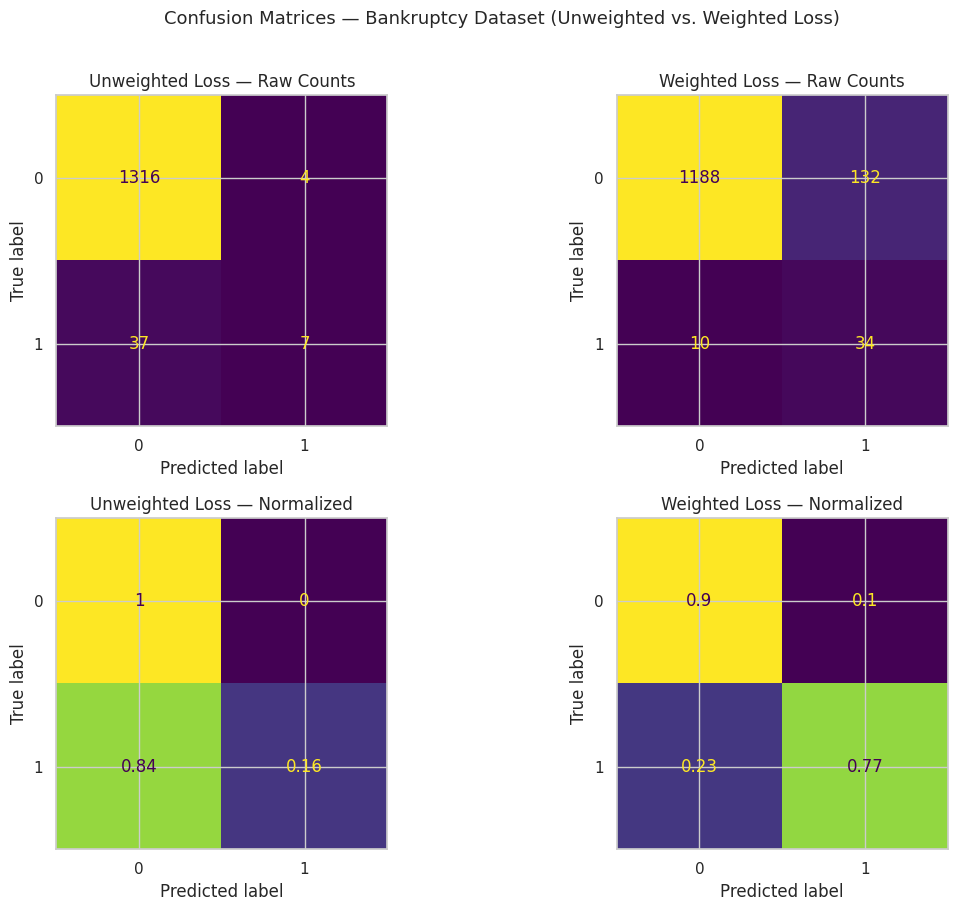

In [70]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# DONE: Create the four types of confusion matrices in their appropriate positions
# Unweighted — Raw Counts
ConfusionMatrixDisplay(cm_unweighted, display_labels=class_names).plot(ax=axes[0, 0], colorbar=False)
axes[0, 0].set_title("Unweighted Loss — Raw Counts")

# Weighted — Raw Counts
ConfusionMatrixDisplay(cm_weighted, display_labels=class_names).plot(ax=axes[0, 1], colorbar=False)
axes[0, 1].set_title("Weighted Loss — Raw Counts")

# Unweighted — Normalized
unweighted_cm_norm = cm_unweighted / cm_unweighted.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(unweighted_cm_norm.round(2), display_labels=class_names).plot(ax=axes[1, 0], colorbar=False)
axes[1, 0].set_title("Unweighted Loss — Normalized")

# Weighted — Normalized
weighted_cm_norm = cm_weighted / cm_weighted.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(weighted_cm_norm.round(2), display_labels=class_names).plot(ax=axes[1, 1], colorbar=False)
axes[1, 1].set_title("Weighted Loss — Normalized")


plt.suptitle("Confusion Matrices — Bankruptcy Dataset (Unweighted vs. Weighted Loss)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
show_todo("Answer the confusion matrix analysis questions below")

**DONE:** Answer these two questions based on your confusion matrices and classification reports above.

**Q1:** For the unweighted model, describe what the confusion matrix reveals about its behavior on the bankruptcy dataset. What do the *off*-diagonal entries tell you? Pay close attention to the false positives and false negatives.

**ANSWER:**
<br>
The unweighted model's confusion matrix reveals that it has low recall, which means that out of all the true bankruptcies, it was only able to predict a small percentage correctly. The off-diagonal entires tell us the number of false positives and false negatives (top right is false positive and bottom left is false negative). We can see that the macro avg for F1 score in the weighted model is larger while the weighted avg for F1 score is lower. This makes sense because class 0 (no bankruptcy) dominates the weighted avg for F1 score, so the weighted model, which sacrificed some recall and accuracy for class 0, has a lower weighted avg. However, since its recall and accuracy for class 1 increased, the macro avg is higher since every class counts the same despite class sample size (macro avg is the better F1 metric to look at when dealing with imbalanced datasets).
<br>

**Q2:** How did the weighted loss change the confusion matrix pattern? Compare specific entries between the two matrices. Interpret your results using precision and recall, and address your narrative in terms of the problem being addressed itself - would we prefer more false positives or false negatives?

**ANSWER:**
<br>
It increased recall, which means that the number of true positive predictions increased. Out of all the predicted positives, we were able to predict more correctly. However, it seems that precision decreased, which indicates that the model was making more false positive predictions. In this case, we would prefer more false positives than false negatives (higher recall and lower precision) as the implications of missing a true positive (predicted wrongly as a false negative) is worse than if we missing a true negative (predicted wrongly as a false positive). We want to avoid/predict true bankruptcies.
<br>

In [ ]:
show_todo("Work through Section 5: Saliency Maps — Where Is the Network Looking?")

## Section 6: Saliency Maps — "Where Is the Network Looking?"

A common criticism of neural networks is that they are "black boxes." You train them, they produce predictions, but you have no idea *what* they are looking at to make their decisions. **Saliency maps** are one of the simplest and most powerful techniques for cracking open that black box.

### The Concept

A saliency map answers a precise question: **which input pixels, if changed slightly, would most affect the model's output?**

Mathematically, for a given input image $x$ and the model's score for class $c$, the saliency is:

$$S = \left| \frac{\partial \text{score}_c}{\partial x} \right|$$

Pixels with large gradient magnitude are the ones the network is "attending" to -- they are the evidence the model relies on for its classification. Pixels with near-zero gradient contribute almost nothing to the decision.

The procedure is straightforward:
1. Set the model to eval mode and enable gradients on the input image
2. Forward pass to get the class score
3. Backward pass to compute gradients with respect to the input
4. Take the absolute value of the gradient; for multi-channel (RGB) images, take the max across channels
5. Normalize to $[0, 1]$ for visualization

We will use **CIFAR-10** for this exercise because its RGB images (32x32x3) produce more visually interesting saliency maps than grayscale FashionMNIST.

In [ ]:
show_note("Saliency maps are the simplest form of 'attribution method' in explainable AI (XAI). More sophisticated techniques include Grad-CAM, Integrated Gradients, and SHAP. But vanilla gradient saliency is where it all starts, and the intuition carries through to every other method.")

### Step 6.1: Load CIFAR-10

You saw this data in the last homework. CIFAR-10 contains 60,000 32x32 color images across 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck. Since CIFAR-10 is RGB (3 channels), we need a transform that normalizes all 3 channels, and our model must use `in_channels=3`.

We also learned about the importance of using **Data Augmentation** techniques to improve the model's ability to generalize to new data it has not seen. However, we did not discuss the importance of using different augmentation transforms for training and testing.

#### Why different transforms for train vs. test matters (a lot)

In most vision pipelines (including CIFAR-10), using **different transforms for training and evaluation is important** because the two phases have different goals:

- **Training goal:** help the model *generalize* by showing it many “plausible variations” of the same image.
- **Test/validation goal:** measure performance on a **fixed, real distribution** as fairly and reproducibly as possible.

So the standard best practice is:

- **Train transform:** *stochastic augmentation* (random crop/flip/rotation/color jitter, etc.) **+** deterministic preprocessing (tensor conversion, normalization).
- **Test/val transform:** *only* deterministic preprocessing** (tensor conversion, normalization; maybe resize/center-crop only if needed).

#### What goes wrong if you don’t separate them?

If you apply training augmentation to the test set
- Your evaluation becomes **noisy and inconsistent**:
- Each epoch/run might evaluate on *different randomized versions* of the test images.
- Accuracy can bounce around because the test set is effectively changing.
- Worse, you’re no longer measuring “performance on CIFAR-10 test images” but “performance on randomly distorted CIFAR-10.”

If you don’t augment training data (train = test transform)
- Training is still “correct,” but usually results in a less generalized model.
- The model sees less variety → more overfitting risk, especially for CNNs that can memorize.

**Augmentation is one of the cheapest, highest-impact regularizers for small-image datasets like CIFAR-10.**

#### What should be the same between train and test?
Usually **normalization should match** (same mean/std), because it’s part of defining the input scale the network expects.

* You should compute the actual mean/std on the **training set only** (common practice), then, apply that normalization to **both** train and test.

#### Rule of thumb
- **Different transforms is the norm and strongly recommended** when you use random augmentation.
- Keep **randomness in training**, keep **determinism in evaluation**.


### Step 6.1.1 - Improve your `get_torchvision_datasets` function

If you created a function to aid in downloading torchvision datasets (which I demonstrated in class a couple weeks ago), then you should make a simple modification to support a training transform and a validation transform:



In [31]:
from lantern.data import get_torchvision_datasets

# CIFAR-10 dataset statistics (computed from training set)
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)

# DONE: Set up training transform with augmentation
cifar10_train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),  # Crop after padding (spatial augmentation)
    transforms.RandomHorizontalFlip(p=0.5),  # 50% chance of horizontal flip
    transforms.RandomRotation(15),  # ±15 degrees (reasonable for CIFAR-10)
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),  # Use actual CIFAR-10 statistics
])

# DONE: Set up test/validation transform WITHOUT augmentation
cifar10_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# DONE: Get your datasets! Be sure to utilize the transforms created above!
cifar10_train_ds, cifar10_test_ds = get_torchvision_datasets(
    "cifar10", 
    train_transform=cifar10_train_transform,
    test_transform=cifar10_test_transform
)

print(f"CIFAR-10 train: {len(cifar10_train_ds)} images")
print(f"CIFAR-10 test:  {len(cifar10_test_ds)} images")
print(f"Classes: {cifar10_test_ds.classes}")
print(f"Image shape: {cifar10_train_ds[0][0].shape}")

CIFAR-10 train: 50000 images
CIFAR-10 test:  10000 images
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Image shape: torch.Size([3, 32, 32])


In [32]:
if RUN_TRAINING_MODE == RunTrainingMode.FULL:
    num_epochs_cifar = 30
elif RUN_TRAINING_MODE == RunTrainingMode.QUICK:
    num_epochs_cifar = 10
else:
    num_epochs_cifar = 0

# DONE: Create a trainer config:
cifar_trainer_config = TrainerConfig(
    trainer_batch_size=64,
    evaluator_batch_size=256,
    learning_rate=0.001,
    optimizer_name="adam",
    weight_decay=1e-5,
    device=accel_device,
    num_epochs=num_epochs_cifar,
    early_stopping_patience=None,
)

# DONE: Create a model config with residual blocks and GAP
cifar_model_config = ModelConfig(
    model_type=ModelType.CNN,
    conv_blocks=[
        ConvBlockConfig(out_channels=32, kernel_size=3, padding=1, pool_size=2, batch_norm=True),
        ResidualBlockConfig(out_channels=32, stride=1),
        ResidualBlockConfig(out_channels=64, stride=2),
    ],
    in_channels=3,
    hidden_units=[128],
    dropout=[0.5],
    use_GAP=True,
)

cifar_model = build_model(input_spec=[32, 32], num_outputs=10, config=cifar_model_config)
print(f"CIFAR-10 CNN Parameters: {cifar_model.num_parameters()}")

CIFAR-10 CNN Parameters: (86858, 86858)


In [33]:
cifar_train_loader, cifar_test_loader = get_dataloaders(
    cifar10_train_ds, cifar10_test_ds,
    train_batch_size=cifar_trainer_config.trainer_batch_size,
    eval_batch_size=cifar_trainer_config.evaluator_batch_size,
)

with Trainer(
    model=cifar_model,
    optimizer=make_optimizer(cifar_model.parameters(), cifar_trainer_config),
    criterion=nn.CrossEntropyLoss(),
    config=cifar_trainer_config,
    run=None,
) as trainer:
    cifar_results = trainer.fit(cifar_train_loader, cifar_test_loader)

print(f"\nCIFAR-10 Results: {cifar_results}")

Epoch 0:
Train Loss=1.6486  Val Loss=1.3515
Train Accuracy=37.91%  Val Accuracy=50.20%
Train F1=0.3735  Val F1=0.4919
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Loss=1.3394  Val Loss=1.2488
Train Accuracy=51.61%  Val Accuracy=54.16%
Train F1=0.5092  Val F1=0.5256
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Loss=1.2160  Val Loss=1.2114
Train Accuracy=56.48%  Val Accuracy=56.65%
Train F1=0.5592  Val F1=0.5534
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 3:
Train Loss=1.1411  Val Loss=1.1300
Train Accuracy=59.49%  Val Accuracy=59.42%
Train F1=0.5902  Val F1=0.5950
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 4:
Train Loss=1.0962  Val Loss=1.0309
Train Accuracy=61.30%  Val Accuracy=62.7

### Step 6.2: Implement `compute_saliency_map()`

**TODO:** Add this function to `src/my_engine/utils.py`. It computes the gradient of the predicted (or specified) class score with respect to the input pixels. Plenty of TODO comments have been added to help guide (and AI) along the way

```python
def compute_saliency_map(
    model: nn.Module,
    image_tensor: torch.Tensor,
    target_class: int = None,
    device: torch.device = None,
) -> tuple[np.ndarray, int]:
    """Compute a saliency map for a single image.

    The saliency map highlights which pixels most influence the model's
    prediction by computing |d(score_c) / d(input)|.

    Args:
        model: Trained model (will be set to eval mode).
        image_tensor: Single image tensor of shape (C, H, W). Do NOT include batch dim.
        target_class: Class index to compute saliency for.
                      If None, uses the model's predicted class (argmax).
        device: Device for computation. If None, uses the model's device.

    Returns:
        Tuple of (saliency_map as 2D numpy array normalized to [0, 1],
                  target_class index used).
    """
    # TODO: Set the model to evaluation mode for correct inference

    # TODO: If device is not specified, use the model's device for computation

    # TODO: Prepare the input image
    #   - Add batch dimension to image_tensor
    #   - Move image to the correct device
    #   - Ensure image.requires_grad is True

    # TODO: Forward pass through the model to get the output logits

    # TODO: Pick the target class to compute the saliency map for
    #   - If target_class is None, use model's predicted class (argmax)

    # TODO: Compute the score for the selected class
    #   - Backpropagate the gradient from this score

    # TODO: Extract the gradient (saliency) from image.grad
    #   - Take the absolute value

    # TODO: For color images (multiple channels), take the max across channels

    # TODO: Normalize the saliency map to [0, 1]

    # TODO: Return the normalized saliency map and the target_class used


    return saliency, target_class
```

In [34]:
from lantern.utils import compute_saliency_map

### Step 6.3: Visualize Saliency Maps

We will pick one test image per CIFAR-10 class, compute its saliency map, and display the original image side-by-side with the saliency heatmap. This lets us see whether the network focuses on semantically meaningful regions (the object itself) or irrelevant background.

Complete the code sections below. (You may copy the `denormalize_image` to your `utils.py` module, as it will be useful down the road.)

In [35]:
def denormalize_image(tensor, mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)):
    """
    Denormalizes a tensor image using the given mean and standard deviation values.

    Args:
        tensor (torch.Tensor): The image tensor to be denormalized. Expected shape: (C, H, W).
        mean (tuple, optional): Mean values for each channel. Default is (0.5, 0.5, 0.5).
        std (tuple, optional): Standard deviation values for each channel. Default is (0.5, 0.5, 0.5).

    Returns:
        torch.Tensor: The denormalized image tensor, with values clipped to [0, 1].
    """
    # Goes from (C,) to (C, H, W)  which broadcasts over (C, H, W) in tensor 
    # Each channel's pixels are denormalized according to their respective means and stds
    mean_t = torch.tensor(mean, dtype=tensor.dtype, device=tensor.device).view(-1, 1, 1)
    std_t = torch.tensor(std, dtype=tensor.dtype, device=tensor.device).view(-1, 1, 1)
    return (tensor * std_t + mean_t).clamp(0, 1)


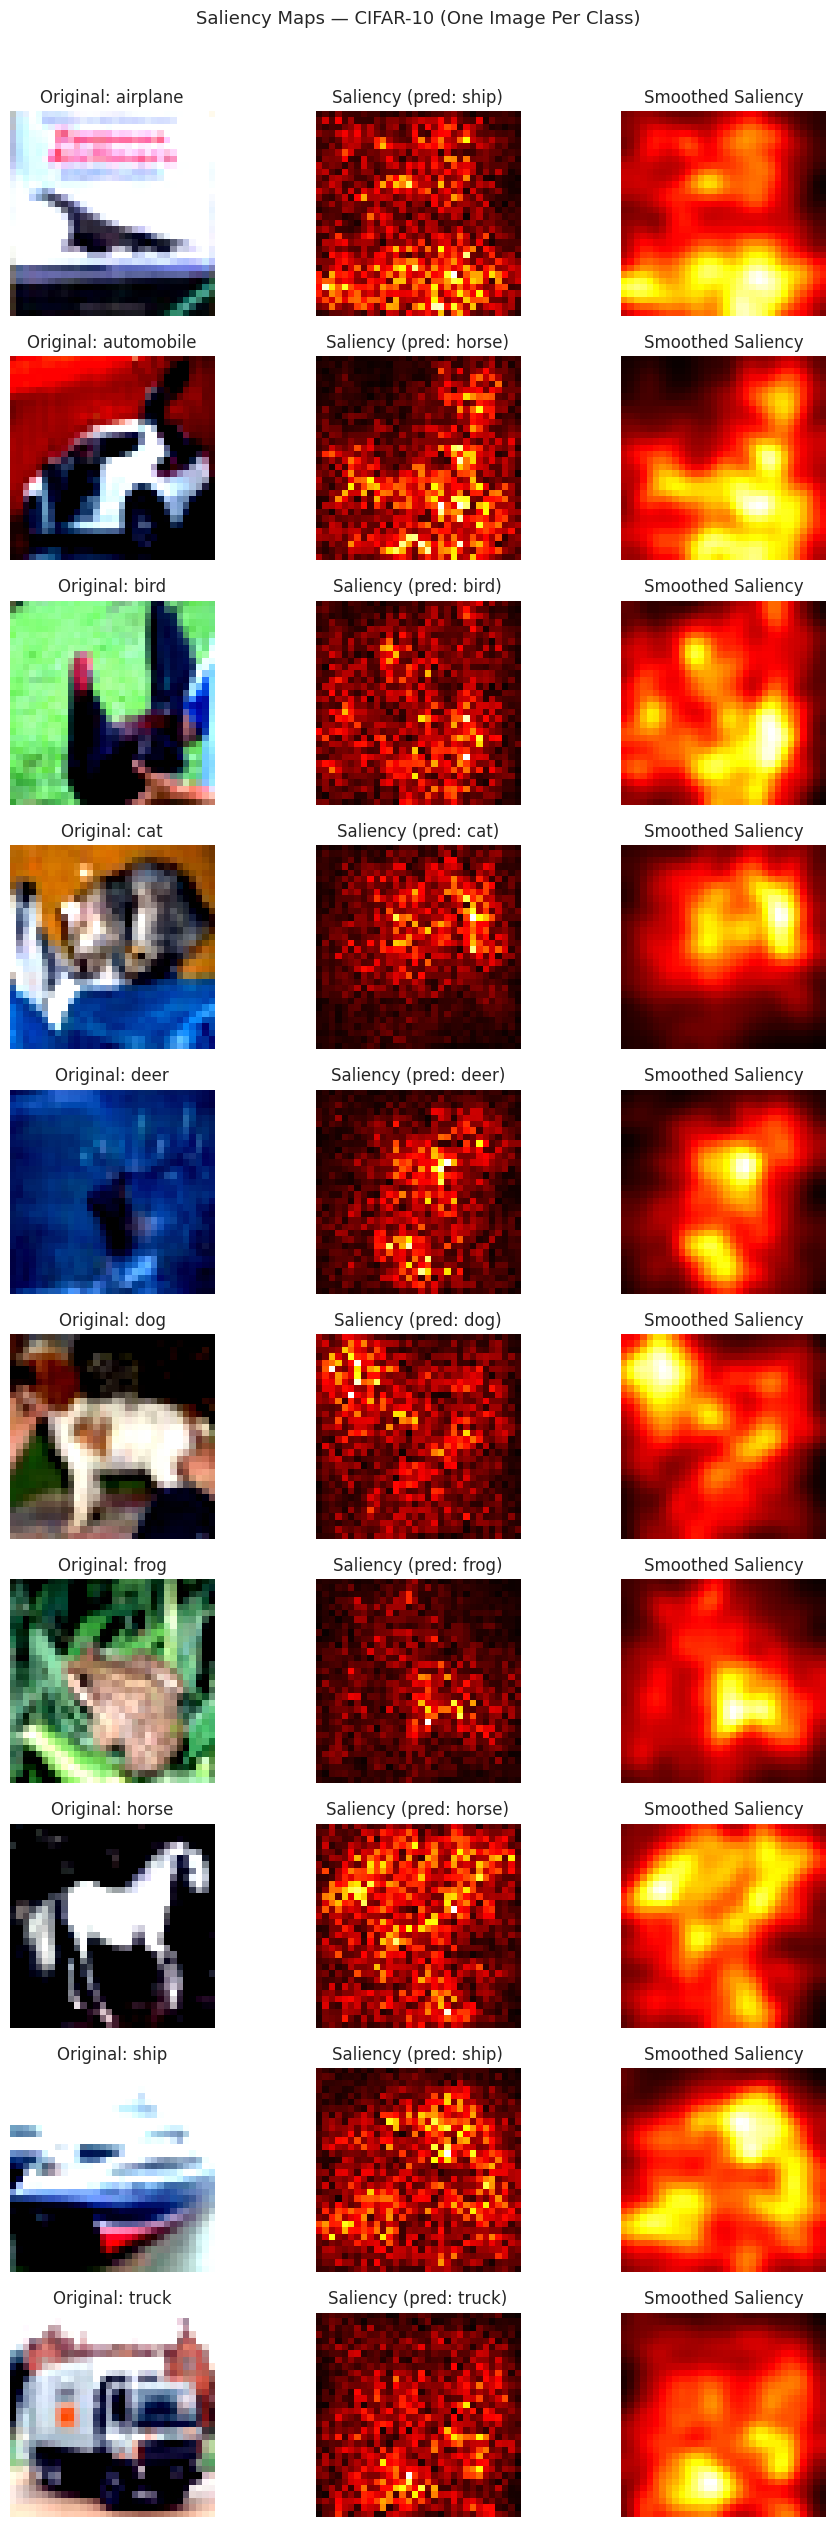

In [36]:
from scipy.ndimage import gaussian_filter

# Let's pick one image per class from the test set and visualize their saliency maps
cifar_classes = cifar10_test_ds.classes
num_display = len(cifar_classes)

# Find one image per class from the test set
class_images = {}
for i in range(len(cifar10_test_ds)):
    img, label = cifar10_test_ds[i]
    if label not in class_images:
        class_images[label] = img
    if len(class_images) == num_display:
        break

# Set up the figure
fig, axes = plt.subplots(num_display, 3, figsize=(10, num_display * 2.5))


for row, cls_idx in enumerate(range(num_display)):
    # Pick the image for class cls_idx
    img_tensor = class_images[cls_idx]

    # Compute the saliency map for the image
    saliency, pred_class = compute_saliency_map(cifar_model, img_tensor, device=accel_device)

    # The image tensor (img_tensor) has been normalized (typically for training neural nets).
    # To visualize it correctly, we "denormalize" it: multiply by std and add mean for each channel.
    # Then, we permute the axes so it's height x width x channel (as expected by matplotlib),
    # and convert it to a numpy array for display.
    img_display = denormalize_image(img_tensor)
    img_display = img_display.permute(1, 2, 0).cpu().numpy() # Then permute the axes

    # Display the original image
    axes[row, 0].imshow(img_display)
    axes[row, 0].set_title(f"Original: {cifar_classes[cls_idx]}")
    axes[row, 0].axis("off")

    # Saliency heatmap
    axes[row, 1].imshow(saliency, cmap="hot")
    axes[row, 1].set_title(f"Saliency (pred: {cifar_classes[pred_class]})")
    axes[row, 1].axis("off")

    # Apply Gaussian blur to the saliency map for smoother visualization
    saliency_smooth = gaussian_filter(saliency, sigma=1.5)
    axes[row, 2].imshow(saliency_smooth, cmap="hot")
    axes[row, 2].set_title("Smoothed Saliency")
    axes[row, 2].axis("off")


plt.suptitle("Saliency Maps — CIFAR-10 (One Image Per Class)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [37]:
show_warning("Saliency maps require gradients with respect to the input. If you forget image.requires_grad_(True) before the forward pass, image.grad will be None and the computation will fail silently or raise an error.")

In [38]:
show_warning("If you do not train the model with enough epochs, the saliency maps will not be clear!")

### Step 6.4: A Closer Look — Comparing Correct vs. Incorrect Predictions

Let's find a few images the model **misclassifies** and visualize their saliency maps. When the model is wrong, the saliency map can reveal *why* -- perhaps it was looking at the background instead of the object, or confusing one shape for another.

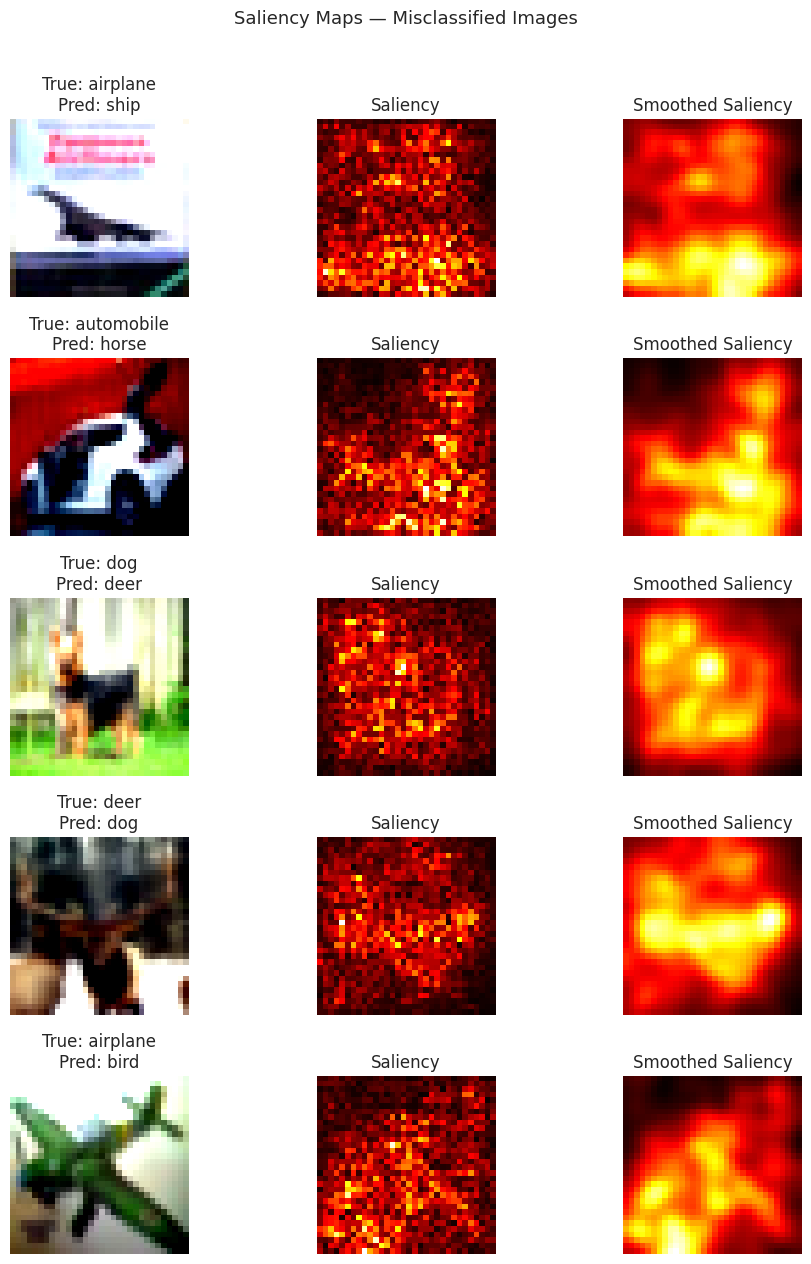

In [37]:
cifar_model.eval()
misclassified = []
num_misclassified = 5

# DONE: Find a list of num_misclassified images
with torch.no_grad():                                                                                                                                                                                                                  
    for img_tensor, true_label in cifar10_test_ds:
        output = cifar_model(img_tensor.unsqueeze(0).to(accel_device))
        pred = torch.argmax(output, dim=1).item()
        if pred != true_label:
            misclassified.append((img_tensor, true_label, pred))
        if len(misclassified) == num_misclassified:
            break

if len(misclassified) > 0:
    # DONE: Use your code above to plot the saliency maps for the misclassified images

    fig, axes = plt.subplots(len(misclassified), 3, figsize=(10, len(misclassified) * 2.5))

    for row, (img_tensor, true_label, pred_label) in enumerate(misclassified):
        saliency, _ = compute_saliency_map(cifar_model, img_tensor, device=accel_device)

        img_display = denormalize_image(img_tensor)
        img_display = img_display.permute(1, 2, 0).cpu().numpy()

        axes[row, 0].imshow(img_display)
        axes[row, 0].set_title(f"True: {cifar_classes[true_label]}\nPred: {cifar_classes[pred_label]}")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(saliency, cmap="hot")
        axes[row, 1].set_title("Saliency")
        axes[row, 1].axis("off")

        saliency_smooth = gaussian_filter(saliency, sigma=1.5)
        axes[row, 2].imshow(saliency_smooth, cmap="hot")
        axes[row, 2].set_title("Smoothed Saliency")
        axes[row, 2].axis("off")

    plt.suptitle("Saliency Maps — Misclassified Images", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("No misclassified images found (model is perfect? unlikely).")

In [40]:
show_todo("Answer the saliency map reflection questions below")

**DONE:** Answer these two questions based on your saliency map visualizations.

**Q1:** Do the saliency maps for correctly classified images highlight semantically meaningful regions? For example, does the network focus on the animal's body for "cat" or "dog", or on the vehicle for "automobile"? Describe what you observe across several classes.

**ANSWER:**
<br>
Yes, the saliency maps highlight the regions that seem to be related to the subject's unique features (like the dog's body) instead of useless pixels like the background. The frog's saliency map also shows this where the shape of the frog is sort of captured in the map, indicating that these pixels are of interest and contributed the most to the prediction.
<br>

**Q2:** Pick one misclassified image and examine its saliency map. Where is the network looking? Can you hypothesize why the misclassification occurred based on what the saliency map reveals?

**ANSWER:**
<br>
The misclassified image of the dog (predicted as a deer) shows a saliency map where pixels above the dog's head has the highest gradient magnitudes, indicating that the model's outputs were most sensitive to these pixels. The problem is that there is essentially nothing related to the dog here (above dog's head), and the model was incorrectly assuming that these pixels corresponded to a feature found in deers that it learned while training.
<br>

In [ ]:
show_section()

---
# Challenges

This week's challenges bridge the gap between architectural theory and visual proof. You will implement the Global Average Pooling layer discussed in the Background, and subsequently extract and visualize the learned kernels from your CIFAR-10 model to witness your feature extractors directly!


## Challenge 1: Visualizing Learned Filters

In Background Section 3, we discussed how CNNs learn feature extractors from data, often resembling hand-crafted edge detectors or color blob detectors in their first layers. Let's prove it by pulling them out of our trained CIFAR-10 model!

**Your task:**
Extract the weights from the *first convolutional layer* of your trained CIFAR-10 model you constructed in the last exercise in the Lab section. Plot them as RGB images. The weights have shape `(out_channels, in_channels, H, W)`. Since `in_channels=3` (RGB), you can interpret each 3x3 filter as a tiny RGB image.

Normalize the weights to [0, 1] before plotting so `matplotlib` can render them.

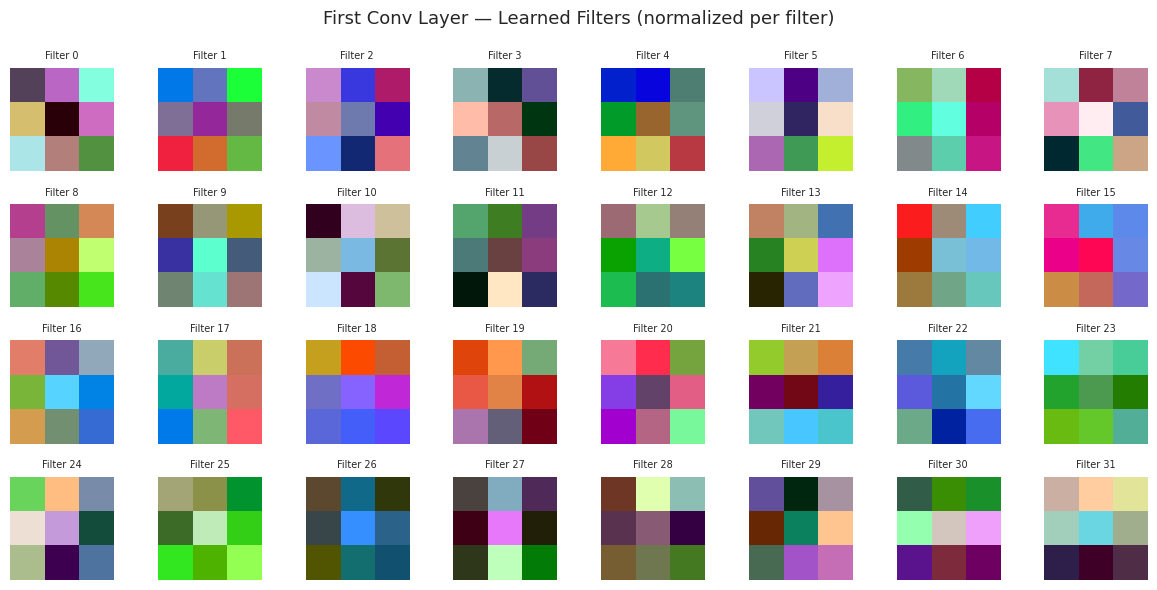

In [38]:

# DONE: Extract and visualize the first layer weights
first_conv = cifar_model.feature_extractor[0]
# The weights are basically the kernel values of size (K, K) = (H, W)
weights = first_conv.weight.data.cpu().clone()  # shape: (out_channels, 3, H, W)

# Normalize each filter individually to [0, 1] for plotting
n_filters = weights.shape[0]
normalized = []
for i in range(n_filters):
    f = weights[i]  # shape: (3, H, W)
    f_min, f_max = f.min(), f.max()
    f_norm = (f - f_min) / (f_max - f_min + 1e-8)
    normalized.append(f_norm.permute(1, 2, 0).numpy())  # (H, W, 3) for matplotlib

# Plot filters in a grid
cols = 8
rows = (n_filters + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.5))
axes = axes.flatten()

for i in range(len(axes)):
    if i < n_filters:
        axes[i].imshow(normalized[i])
        axes[i].set_title(f"Filter {i}", fontsize=7)
    axes[i].axis("off")

plt.suptitle("First Conv Layer — Learned Filters (normalized per filter)", fontsize=13)
plt.tight_layout()
plt.show()


## Challenge 2: Transfer Learning

Deep learning models often require massive datasets and significant computational resources to train from scratch. **Transfer Learning** is a powerful technique that addresses this by allowing us to take a model already trained on a massive, general dataset (like ImageNet with 1.2 million images) and "transfer" its learned knowledge to a new, smaller task (like CIFAR-10).

There are two primary strategies for transfer learning:
1.  **Feature Extraction:** We "freeze" the weights of the pretrained layers and only train the final "head" (classifier). The pretrained layers act as a fixed feature extractor.
2.  **Fine-Tuning:** We initialize the model with pretrained weights and then train the entire network (or just some deeper layers) on the new task with a very small learning rate.

Transfer learning is especially effective when your new dataset is small, as it prevents overfitting and speeds up convergence by starting with a model that already "understands" basic visual features like edges, textures, and shapes.

**Your task:**
1.  **Load a Pretrained Model:** Use `torchvision.models.resnet18(weights='IMAGENET1K_V1')`.
2.  **Modify the Classifier:** Replace the final fully connected layer (`model.fc`) to output 10 classes instead of 1000.
3.  **Prepare the Data:** ResNet-18 was trained on 224x224 images. While it can take 32x32 images, its features are most effective when the input is resized. Add a `transforms.Resize(224)` step to your pipeline.
4.  **Fine-Tune:** Set up a `Trainer` to train this model on CIFAR-10. Since this is a pretrained model, use a smaller learning rate (e.g., `1e-4`) to avoid "clobbering" the useful weights it already has.

In [39]:
from torchvision import models
from lantern.trainer import Trainer
from lantern.config import TrainerConfig, MetricsConfig

# 1. Load pretrained ResNet-18
resnet_18 = models.resnet18(weights="IMAGENET1K_V1")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 156MB/s] 


In [53]:
# 2. Replace the final FC layer to be only 10 classes
# ResNet-18's final layer is 'fc', and it has 512 input features! So, much change!
resnet_18.fc = nn.Linear(resnet_18.fc.in_features, 10)
resnet_18.num_outputs = 10

In [54]:
# 3. Prepare data with a transform that utilizes resizing (ResNet-18 expects 224x224)
# CIFAR-10 dataset statistics (computed from training set)
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)

# DONE: Set up training transform with augmentation
cifar10_train_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(p=0.5),  # 50% chance of horizontal flip
    transforms.RandomRotation(15),  # ±15 degrees (reasonable for CIFAR-10)
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),  # Use actual CIFAR-10 statistics
])

# DONE: Set up test/validation transform WITHOUT augmentation
cifar10_test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])
resnet_cifar10_train, resnet_cifar10_test = get_torchvision_datasets("cifar10", train_transform=cifar10_train_transform, test_transform=cifar10_test_transform)

In [55]:

# 4. Set up our data loader
resnet_train_dl, resnet_test_dl = get_dataloaders(
    resnet_cifar10_train, resnet_cifar10_test,
    train_batch_size=64,
    eval_batch_size=256,
)

# 5. Set up the epochs
# Much fewer epochs for transfer learning demonstration if not in FULL mode
if RUN_TRAINING_MODE == RunTrainingMode.FULL:
    num_epochs_cifar = 10
elif RUN_TRAINING_MODE == RunTrainingMode.QUICK:
    num_epochs_cifar = 3
else:
    num_epochs_cifar = 0


In [56]:
# [OPTIONAL] - Freeze the backbone of the network. Train only the fully connected head
for name, param in resnet_18.named_parameters():
    if not name.startswith('fc.'):
        param.requires_grad = False

# Create our TrainerConfig
resnet_trainer_config = TrainerConfig(
    trainer_batch_size=resnet_train_dl.batch_size,
    evaluator_batch_size=resnet_test_dl.batch_size,
    learning_rate=0.0005,
    device=accel_device,
    num_epochs=num_epochs_cifar,
)

In [57]:
# Set up our trainer using the pre-trained model, with the config
optimizer = make_optimizer(resnet_18.parameters(), resnet_trainer_config)

**WARNING:** Though you need fewer epochs, each epoch will be *slow* as you are fine tuning a much more complex model. So, if it looks like it's stuck, be patient...

In [58]:
print("Starting Transfer Learning Fine-tuning...")
# Run the trainer!
with Trainer(
    model=resnet_18,
    optimizer=optimizer,
    criterion=nn.CrossEntropyLoss(),
    config=resnet_trainer_config,
    run=None
) as trainer:
    trainer.fit(resnet_train_dl, resnet_test_dl)

Starting Transfer Learning Fine-tuning...
Epoch 0:
Train Loss=1.1283  Val Loss=0.7361
Train Accuracy=64.47%  Val Accuracy=75.81%
Train F1=0.6437  Val F1=0.7573
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Loss=0.8073  Val Loss=0.6641
Train Accuracy=73.18%  Val Accuracy=77.51%
Train F1=0.7314  Val F1=0.7709
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Loss=0.7504  Val Loss=0.6290
Train Accuracy=74.47%  Val Accuracy=78.37%
Train F1=0.7443  Val F1=0.7825
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 3:
Train Loss=0.7156  Val Loss=0.6240
Train Accuracy=75.45%  Val Accuracy=78.30%
Train F1=0.7543  Val F1=0.7823
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 4:
Train Loss=0.7101  Val Loss=0.585


### Analysis / Reflection

**DONE:** Do a bit of research with AI on the above exercise. Then answer the following questions:

1. In your own words, what knowledge are we “borrowing” when we use a ResNet pretrained on ImageNet for CIFAR-10? How does that differ from training the same architecture from scratch?

**ANSWER:**
We are borrowing the "learned knowledge" that a ResNet developed while being trained on ImageNet. This is different from training the same architecture from scratch as the training data is inherently different. We are leveraging the generality of the pretrained ResNet, which is why the accuracy is not too high on the CIFAR-10 dataset.

2. Which parts of ResNet’s representation do you expect to be most reusable for CIFAR-10 (early vs late layers), and why?

**ANSWER:**

I would argue that the early layers of ResNet are most reusable as those early layers probably capturing low-level, general features like edges, corners, color gradients, textures, etc. Meanwhile, late layers deal with higher-level features that combine information from the earlier layers. They are also closer to the classifier head, which would also make it less generalizable/create a mismatch with datasets of different resolutions like CIFAR-10.

3. Look up how to freeze layers so that you are only training the final layer. (Code provided above, commented). Retrain. How well did it work? Did fine-tuning additional layers beyond the head improve test accuracy? If yes, why might that be? If not, what hypotheses can you offer (e.g., overfitting, learning rate choice, data size)?

**ANSWER:**
It seems that the frozen layers lead to worse performance. This is probably because we are not changing the model's understanding and feature extraction that was learned on ImageNet. Meanwhile, if we train all layers, we are adjusting the weights and biases of all layers to adapt to CIFAR-10's distribution. However, there could be problems that may hinder performance from improving dramatically, such as overfitting (since CIFAR-10's dataset is smaller), learning rate is too high, and the resolution mismatch.


## Challenge 3: Sweep Competition on CIFAR-10

**This is a competition!** Your task is to develop a sweep configuration of CNN architectures over all parameters you've learned about to date to obtain the highest **validation accuracy** on the CIFAR-10 dataset.

**Details:**<br>
* You've learned a variety of techniques in this week's work. Create an updated sweep configuration for the CIFAR-10 dataset. You should be including:
  * batch normalization
  * global average pooling
  * residual connections
* Then, once you have the parameters for the best model, generate a 10x10 confusion matrix (plotted, using the visualization above) and log it to wandb.
* You must use `project = "csci357-hw06-chal03-cifar"` and the class `entity` variable. For example, assuming you nameded your sweep config dictionary `cifar10_sweep_config`:
   ```python
   sweep_id = wandb.sweep(
       entity=entity,
       name="csci357-hw07-chal03-cifar",
       sweep=cifar10_sweep_config,
   )
   ```
* Log the total number of parameters in your model to wandb as `num_parameters`
* Log the trainable number of parameters in your model to wandb as `num_train_parameters`
* Add your wanb variable `user_initials` so that every run has your initials as a prefix with an `_`
* Please log the names `train_loss`, `train_accuracy`, `val_loss` and `val_accuracy`
* If you are using LR scheduling, be sure you are logging `learning_rate`


**`wandb` requirements:
* You should use the course entity
* Project name: f`hw07_chal03

In [59]:
# CIFAR-10 dataset statistics (computed from training set)
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)
# DONE: Set up your datasets with the train and test transforms
cifar10_train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),  # 50% chance of horizontal flip
    transforms.RandomRotation(15),  # ±15 degrees (reasonable for CIFAR-10)
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),  # Use actual CIFAR-10 statistics
])

# DONE: Set up test/validation transform WITHOUT augmentation
cifar10_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

cifar10_train_ds, cifar10_test_ds = get_torchvision_datasets("cifar10", train_transform=cifar10_train_transform, test_transform=cifar10_test_transform)


In [60]:

# DONE: Set up your cifar10_sweep_config
num_epochs = 15
sweep_count = 20
if RUN_TRAINING_MODE != RunTrainingMode.FULL:
    num_epochs = 5
    sweep_count = 5

cifar10_sweep_config = {
    "method": "bayes",
    "metric": {
        "name": "val_accuracy",
        "goal": "maximize"
    },
    "parameters": {
        # Fixed parameters
        "evaluator_batch_size": { "value": 256 },
        "num_epochs": {"value": num_epochs},
        "model_type": { "value": "cnn" },
        "in_channels": { "value": 3 },
        "early_stopping_patience": { "value": 5 },

        # Global Average Pooling toggle
        "use_GAP": {
            "values": [True, False]
        },

        # Searchable parameters
        "trainer_batch_size": {
            "values": [128, 256]
        },
        "learning_rate": {
            "min": 0.0001,
            "max": 0.01,
            "distribution": "log_uniform_values"
        },
        "optimizer_name": {
            "values": ["adam", "momentum"]
        },
        "conv_blocks": {
            "values": [
                # --- Plain CNN with batch norm ---
                [
                    {"block_type": "conv", "out_channels": 32, "kernel_size": 3, "stride": 1, "padding": 1, "pool_size": 2, "batch_norm": True},
                    {"block_type": "conv", "out_channels": 64, "kernel_size": 3, "stride": 1, "padding": 1, "pool_size": 2, "batch_norm": True},
                ],
                [
                    {"block_type": "conv", "out_channels": 32, "kernel_size": 3, "stride": 1, "padding": 1, "pool_size": 2, "batch_norm": True},
                    {"block_type": "conv", "out_channels": 64, "kernel_size": 3, "stride": 1, "padding": 1, "pool_size": 2, "batch_norm": True},
                    {"block_type": "conv", "out_channels": 128, "kernel_size": 3, "stride": 1, "padding": 1, "pool_size": 2, "batch_norm": True},
                ],
                # --- Residual architectures (stride-based downsampling, no pool_size needed) ---
                [
                    {"block_type": "conv", "out_channels": 32, "kernel_size": 3, "stride": 1, "padding": 1, "pool_size": 2, "batch_norm": True},
                    {"block_type": "residual", "out_channels": 32, "stride": 1},
                    {"block_type": "residual", "out_channels": 64, "stride": 2},
                ],
                [
                    {"block_type": "conv", "out_channels": 32, "kernel_size": 3, "stride": 1, "padding": 1, "pool_size": 2, "batch_norm": True},
                    {"block_type": "residual", "out_channels": 64, "stride": 1},
                    {"block_type": "residual", "out_channels": 64, "stride": 2},
                    {"block_type": "residual", "out_channels": 128, "stride": 2},
                ],
                [
                    {"block_type": "conv", "out_channels": 64, "kernel_size": 3, "stride": 1, "padding": 1, "pool_size": 2, "batch_norm": True},
                    {"block_type": "residual", "out_channels": 64, "stride": 1},
                    {"block_type": "residual", "out_channels": 128, "stride": 2},
                ],
            ]
        },
        "hidden_units": {
            "values": [
                [512, 128],
                [256, 128],
                [512, 256],
            ]
        },
        "dropout": {
            "values": [
                [0.3, 0.2],
                [0.3, 0.1],
                [0.5, 0.3],
            ]
        },
        "weight_decay": {
            "min": 0.00001,
            "max": 0.01,
            "distribution": "log_uniform_values"
        },
        "momentum": {
            "min": 0.8,
            "max": 0.99,
            "distribution": "uniform"
        },
        "scheduler_gamma": {
            "min": 0.3,
            "max": 0.99,
            "distribution": "uniform"
        }
    }
}


In [62]:
from lantern.sweep import make_train_sweep
project = "csci357-hw07-chal03-cifar"
datasets = (cifar10_train_ds, cifar10_test_ds)
input_spec = [32, 32]
num_outputs = 10

train_sweep = make_train_sweep(
    wandb_project_name=project,
    wandb_entity_name=entity,
    wandb_name_prefix=user_initials,
    datasets=datasets,
    device=accel_device,
    input_spec=input_spec,
    num_outputs=num_outputs,
    metrics_config_param=MetricsConfig(task="multiclass", names=["accuracy"])
)

from lantern.sweep import print_sweep_info, terminate_sweep

sweep_id = wandb.sweep(
    entity=entity,
    sweep=cifar10_sweep_config,
    project=project
)
print_sweep_info(sweep_id)

wandb.agent(sweep_id=sweep_id, function=train_sweep, count=sweep_count)

print("\n" + "="*60)
print("✓ Sweep complete! All runs finished.")
print("\n" + "="*60)

print_sweep_info(sweep_id)
terminate_sweep(sweep_id)

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Create sweep with ID: ts7m3a3s
Sweep URL: https://wandb.ai/bucknell-university-csci357-2026sp/csci357-hw07-chal03-cifar/sweeps/ts7m3a3s
Sweep ts7m3a3s has 0 runs
Sweep ts7m3a3s expected None runs
Sweep ts7m3a3s current state is: PENDING


wandb: Agent Starting Run: nt0srb1w with config:
wandb: 	conv_blocks: [{'batch_norm': True, 'block_type': 'conv', 'kernel_size': 3, 'out_channels': 32, 'padding': 1, 'pool_size': 2, 'stride': 1}, {'block_type': 'residual', 'out_channels': 32, 'stride': 1}, {'block_type': 'residual', 'out_channels': 64, 'stride': 2}]
wandb: 	dropout: [0.3, 0.2]
wandb: 	early_stopping_patience: 5
wandb: 	evaluator_batch_size: 256
wandb: 	hidden_units: [512, 128]
wandb: 	in_channels: 3
wandb: 	learning_rate: 0.0015366715115243677
wandb: 	model_type: cnn
wandb: 	momentum: 0.8403045967647651
wandb: 	num_epochs: 15
wandb: 	optimizer_name: adam
wandb: 	scheduler_gamma: 0.6457444003783517
wandb: 	trainer_batch_size: 256
wandb: 	use_GAP: False
wandb: 	weight_decay: 0.00017333252386798117
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: cb073 (bucknell-university-csci357-2026sp) to https://api.wandb.ai. Use `wandb login --relogin` to force relog

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb.config: {'conv_blocks': [{'batch_norm': True, 'block_type': 'conv', 'kernel_size': 3, 'out_channels': 32, 'padding': 1, 'pool_size': 2, 'stride': 1}, {'block_type': 'residual', 'out_channels': 32, 'stride': 1}, {'block_type': 'residual', 'out_channels': 64, 'stride': 2}], 'dropout': [0.3, 0.2], 'early_stopping_patience': 5, 'evaluator_batch_size': 256, 'hidden_units': [512, 128], 'in_channels': 3, 'learning_rate': 0.0015366715115243677, 'model_type': 'cnn', 'momentum': 0.8403045967647651, 'num_epochs': 15, 'optimizer_name': 'adam', 'scheduler_gamma': 0.6457444003783517, 'trainer_batch_size': 256, 'use_GAP': False, 'weight_decay': 0.00017333252386798117}
Run name set to: CMB_cnn_bs256_lr0.0015366715115243677_h512x128
Epoch 0:
Train Accuracy=40.33%  Val Accuracy=53.89%
--> New best checkpoint saved: ./checkpoints/csci357-hw07-chal03-cifar-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw07-chal03-cifar-last.pt
Epoch 1:
Train Accuracy=53.60%  Val Accuracy=57.80%
-

...

wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: jt3vx6vd with config:
wandb: 	conv_blocks: [{'batch_norm': True, 'block_type': 'conv', 'kernel_size': 3, 'out_channels': 64, 'padding': 1, 'pool_size': 2, 'stride': 1}, {'block_type': 'residual', 'out_channels': 64, 'stride': 1}, {'block_type': 'residual', 'out_channels': 128, 'stride': 2}]
wandb: 	dropout: [0.3, 0.2]
wandb: 	early_stopping_patience: 5
wandb: 	evaluator_batch_size: 256
wandb: 	hidden_units: [256, 128]
wandb: 	in_channels: 3
wandb: 	learning_rate: 0.001311516012726487
wandb: 	model_type: cnn
wandb: 	momentum: 0.8441305388286701
wandb: 	num_epochs: 15
wandb: 	optimizer_name: adam
wandb: 	scheduler_gamma: 0.6595311788324876
wandb: 	trainer_batch_size: 256
wandb: 	use_GAP: False
wandb: 	weight_decay: 0.0008182041715874644
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


wandb.config: {'conv_blocks': [{'batch_norm': True, 'block_type': 'conv', 'kernel_size': 3, 'out_channels': 64, 'padding': 1, 'pool_size': 2, 'stride': 1}, {'block_type': 'residual', 'out_channels': 64, 'stride': 1}, {'block_type': 'residual', 'out_channels': 128, 'stride': 2}], 'dropout': [0.3, 0.2], 'early_stopping_patience': 5, 'evaluator_batch_size': 256, 'hidden_units': [256, 128], 'in_channels': 3, 'learning_rate': 0.001311516012726487, 'model_type': 'cnn', 'momentum': 0.8441305388286701, 'num_epochs': 15, 'optimizer_name': 'adam', 'scheduler_gamma': 0.6595311788324876, 'trainer_batch_size': 256, 'use_GAP': False, 'weight_decay': 0.0008182041715874644}
Run name set to: CMB_cnn_bs256_lr0.001311516012726487_h256x128
Epoch 0:
Train Accuracy=39.78%  Val Accuracy=49.47%
--> New best checkpoint saved: ./checkpoints/csci357-hw07-chal03-cifar-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw07-chal03-cifar-last.pt
Epoch 1:
Train Accuracy=52.35%  Val Accuracy=59.27%
-->

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_accuracy,▁▃▄▅▆▆▆▇▇▇▇████
val_accuracy,▁▃▄▅▅▆▆▆▆█▇████
epoch,14
learning_rate,0.00131
train_accuracy,0.76436
val_accuracy,0.779


Run complete! val_accuracy: 77.90%

✓ Sweep complete! All runs finished.

Sweep ts7m3a3s has 20 runs
Sweep ts7m3a3s expected None runs
Sweep ts7m3a3s current state is: RUNNING
Stopping sweep bucknell-university-csci357-2026sp/csci357-hw07-chal03-cifar/ts7m3a3s
Sweep bucknell-university-csci357-2026sp/csci357-hw07-chal03-cifar/ts7m3a3s stopped successfully


True

Once you've completed your sweep, figure out which one is best. Use the `wandb.Api()` object to find your sweep and retrieve the configuration settings for the best run. (It's actually pretty easy to do!) Then, build your TrainerConfig and ModelConfig based on those. Rerun once and generate a confusion matrix for it using scikit-learn's `ConfusionMatrixDisplay` function that you used above.

In [64]:
# Retrieve the best run from your sweep
api = wandb.Api()

sweep = api.sweep(f"{entity}/{project}/{sweep_id}")
best_run = sweep.best_run()

print("Best run ID:", best_run.id)
print("Best run name:", best_run.name)
print("Best val_accuracy:", best_run.summary["val_accuracy"])
print("Best config:", best_run.config)

wandb: Sorting runs by -summary_metrics.val_accuracy


Best run ID: mpiv3t2f
Best run name: CMB_cnn_bs128_lr0.00045047641711277255_h512x256
Best val_accuracy: 0.7958999872207642
Best config: {'dropout': [0.3, 0.2], 'use_GAP': False, 'momentum': 0.858016146493523, 'model_type': 'cnn', 'num_epochs': 15, 'pin_memory': True, 'conv_blocks': [{'stride': 1, 'padding': 1, 'pool_size': 2, 'batch_norm': True, 'block_type': 'conv', 'kernel_size': 3, 'out_channels': 64}, {'stride': 1, 'block_type': 'residual', 'out_channels': 64}, {'stride': 2, 'block_type': 'residual', 'out_channels': 128}], 'in_channels': 3, 'hidden_units': [512, 256], 'model_config': {'dropout': [0.3, 0.2], 'use_GAP': False, 'model_type': 'CNN', 'conv_blocks': [{'stride': 1, 'padding': 1, 'pool_size': 2, 'batch_norm': True, 'kernel_size': 3, 'out_channels': 64}, {'stride': 1, 'out_channels': 64}, {'stride': 2, 'out_channels': 128}], 'in_channels': 3, 'hidden_units': [512, 256]}, 'weight_decay': 0.0012064983027309031, 'learning_rate': 0.00045047641711277255, 'num_parameters': 463476

In [72]:
cfg = best_run.config
print(cfg)
print(cfg["conv_blocks"])

model_config = ModelConfig(
    model_type=cfg["model_type"],
    hidden_units=cfg["hidden_units"],
    conv_blocks=cfg["conv_blocks"],
    in_channels=cfg["in_channels"],
    use_GAP=cfg["use_GAP"],
    dropout=cfg["dropout"],
)

trainer_config = TrainerConfig(
    num_epochs=cfg["num_epochs"],
    trainer_batch_size=cfg["trainer_batch_size"],
    evaluator_batch_size=cfg["evaluator_batch_size"],
    learning_rate=cfg["learning_rate"],
    optimizer_name=cfg["optimizer_name"],
    weight_decay=cfg["weight_decay"],
    momentum=cfg["momentum"],
    scheduler_gamma=cfg["scheduler_gamma"],
    early_stopping_patience=cfg["early_stopping_patience"],
    device=accel_device
)
input_spec = [32, 32]
best_model = build_model(input_spec=input_spec, num_outputs=num_outputs, config=model_config)
optimizer = make_optimizer(best_model.parameters(), trainer_config)
criterion = nn.CrossEntropyLoss()

train_loader = DataLoader(
    cifar10_train_ds, batch_size=cfg["trainer_batch_size"], shuffle=True
)
val_loader = DataLoader(
    cifar10_test_ds, batch_size=cfg["evaluator_batch_size"], shuffle=False
)

with Trainer(
    model=best_model,
    optimizer=optimizer,
    criterion=criterion,
    config=trainer_config,
    metrics_config=MetricsConfig(task="multiclass", names=["accuracy"]),
    run=None
) as trainer:
    trainer.fit(train_loader, val_loader)

{'dropout': [0.3, 0.2], 'use_GAP': False, 'momentum': 0.858016146493523, 'model_type': 'cnn', 'num_epochs': 15, 'pin_memory': True, 'conv_blocks': [{'stride': 1, 'padding': 1, 'pool_size': 2, 'batch_norm': True, 'block_type': 'conv', 'kernel_size': 3, 'out_channels': 64}, {'stride': 1, 'block_type': 'residual', 'out_channels': 64}, {'stride': 2, 'block_type': 'residual', 'out_channels': 128}], 'in_channels': 3, 'hidden_units': [512, 256], 'model_config': {'dropout': [0.3, 0.2], 'use_GAP': False, 'model_type': 'CNN', 'conv_blocks': [{'stride': 1, 'padding': 1, 'pool_size': 2, 'batch_norm': True, 'kernel_size': 3, 'out_channels': 64}, {'stride': 1, 'out_channels': 64}, {'stride': 2, 'out_channels': 128}], 'in_channels': 3, 'hidden_units': [512, 256]}, 'weight_decay': 0.0012064983027309031, 'learning_rate': 0.00045047641711277255, 'num_parameters': 4634762, 'optimizer_name': 'adam', 'trainer_config': {'device': 'cuda', 'momentum': 0.858016146493523, 'num_epochs': 15, 'pin_memory': True, '

Best Loss — Per-Class Metrics
              precision    recall  f1-score   support

    airplane       0.88      0.76      0.82      1000
  automobile       0.87      0.93      0.90      1000
        bird       0.84      0.65      0.73      1000
         cat       0.55      0.73      0.63      1000
        deer       0.84      0.74      0.78      1000
         dog       0.66      0.79      0.72      1000
        frog       0.84      0.84      0.84      1000
       horse       0.88      0.81      0.85      1000
        ship       0.94      0.83      0.88      1000
       truck       0.84      0.91      0.87      1000

    accuracy                           0.80     10000
   macro avg       0.81      0.80      0.80     10000
weighted avg       0.81      0.80      0.80     10000



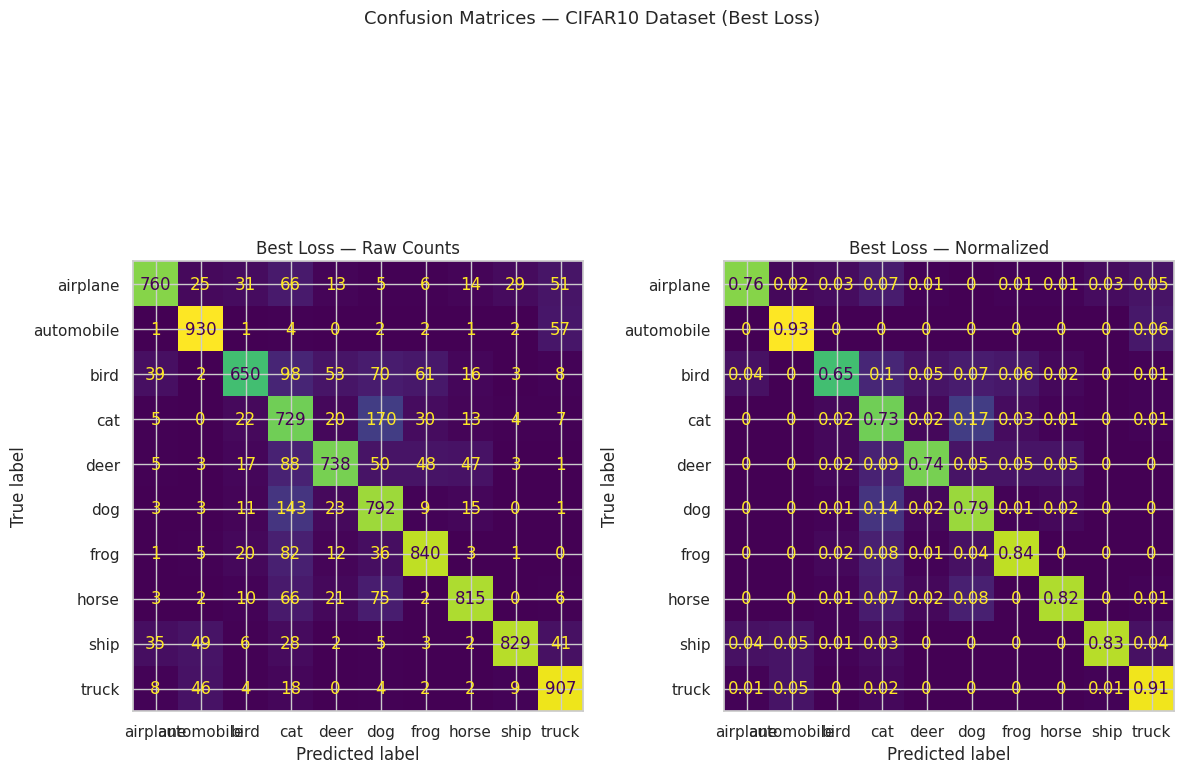

In [75]:
from lantern.utils import compute_confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
# DONE: Use compute_confusion_matrix on the best model with the validation data loader
cm_best, all_preds_best, all_labels_best = compute_confusion_matrix(best_model, val_loader, accel_device)

# DONE: Get the actual class names, not just indices, then pass to classification_report
class_names = cifar10_test_ds.classes

print("Best Loss — Per-Class Metrics")
print(classification_report(all_labels_best, all_preds_best, target_names=class_names))

fig, axes = plt.subplots(1, 2, figsize=(12, 9))

# DONE: Create the confusion matrices in their appropriate positions
# Raw counts
ConfusionMatrixDisplay(cm_best, display_labels=class_names).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Best Loss — Raw Counts")

# best — Normalized
cm_best_norm = cm_best / cm_best.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_best_norm.round(2), display_labels=class_names).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Best Loss — Normalized")


plt.suptitle("Confusion Matrices — CIFAR10 Dataset (Best Loss)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Analysis
**Which class performed the best? Which was the worst? For the worst class, which classes were predicted incorrectly?**

The class that performed the best was the automobile. The class that performed the worst was the bird. It confused some of the true birds as cats (False Negative). As for the predicted birds, the class that it confused it with the most was the airplane (False Positive). However, it seems that the false positive rate is lower than the false negative rate (higher precision than recall).

# Career Survey

## Understanding Distillation as a Professional Skill

Article: https://www.cnbc.com/2026/02/24/anthropic-openai-china-firms-distillation-deepseek.html

In February 2026, Anthropic publicly accused three Chinese AI firms — DeepSeek, Moonshot AI, and MiniMax — of running "industrial-scale" distillation attack campaigns, generating over 16 million exchanges with Claude through 24,000 fraudulent accounts. Meanwhile, OpenAI has already turned distillation into a commercial product, offering it through their API to help developers build faster, cheaper models. Whether you end up working at a frontier AI lab, a startup, or a company that simply *deploys* AI, knowledge distillation is no longer an academic curiosity — it is a core production technique that shapes how modern AI systems are built, compressed, and shipped. Understanding how it works is fast becoming a baseline expectation for anyone entering the AI industry.

**Essay Prompts**
Choose a prompt below, then write a 150-200 word (or more) that offers your own perspective after digging your resources for information.

1. **The Mechanics and Value of Distillation** — In your own words, explain how knowledge distillation works: what is the role of the teacher and student models, how does training with soft labels differ from standard supervised learning, and why does this technique matter for deploying AI in real-world products? Use the DeepSeek case as a concrete example of the technique's power.

2. **Distillation in the AI Job Market** — OpenAI now offers distillation as a commercial API service, and companies like Anthropic build entire product tiers (Haiku, Sonnet, Opus) that almost certainly rely on it. Research one current job posting in ML engineering or AI development and reflect: what technical skills related to model compression, fine-tuning, or distillation does it require? What does this tell you about what employers expect new graduates to know?

3. **Building Efficient AI: Where Would You Apply It?** — Imagine you are a machine learning engineer at a startup that cannot afford to run a large frontier model at inference time. Describe a practical scenario where you would use distillation to solve a real problem. What would your teacher model be, what task would the student need to perform, and what tradeoffs would you accept in performance to achieve your cost and speed goals?


**ANSWER:**

<br>
3. Let's say I am at a startup that is creating generative agents (simulating human behavior) and I need powerful LLMs to mimic humans. If I were to create my own LLM, this would take significant compute and time, which is something I do not have. Using a less powerful model might not provide realistic outputs to replicate human responses. That's when I would use distillation on models like GPT-5.2. The task that the student would need to perform are generating responses that are human-like with a big enough context window. I would tradeoff a smaller context window and less cohere responses if it would let me conduct faster inference since the simulated agents would not need too much context (simulating thousands of small agents rather than a few gigantic agents). This would be an efficient way for the startup to get decent performance at a fraction of the cost of either using an LLM provider's API or training my own LLM.
<br>


[source](https://www.datacamp.com/blog/distillation-llm)




# Society — The Ethics, Policy, and Power of AI Knowledge Transfer

Article - https://www.cnbc.com/2026/02/24/anthropic-openai-china-firms-distillation-deepseek.html

The distillation controversy isn't just a technical dispute — it's a window into some of the most contested questions in AI policy today. Anthropic and OpenAI are framing unauthorized distillation as a national security threat, warning that firms could use extracted capabilities for "offensive cyber operations, disinformation campaigns, and mass surveillance". Yet critics have been quick to point out that both companies practice distillation themselves, raising uncomfortable questions about whether these statements reflect genuine safety concerns or a corporate desire to protect competitive advantage. At the same time, the U.S. government is tightening AI chip export controls, restricting access to advanced hardware that powers these models — turning a machine learning technique into a flashpoint in a much larger geopolitical contest. This story puts the societal stakes of AI development front and center.

**Essay Prompts**
Choose a prompt below, then write a 150-200 word (or more) that offers your own perspective after digging your resources for information.

1. **IP Theft or Standard Practice? Drawing the Line** — Anthropic acknowledges that "AI firms routinely distill their own models" — yet calls the same technique a threat when used by competitors without permission. Is unauthorized distillation fundamentally different from other forms of reverse engineering or competitive intelligence? Where do you think the ethical and legal line should be, and who should have the authority to draw it?

2. **The Global AI Divide and the Ethics of Access** — Distillation allows smaller teams with fewer resources to build powerful AI systems at a fraction of the cost of frontier model training. In a world where access to AI capabilities is increasingly tied to geopolitical alliances and corporate gatekeeping, is restricting distillation a way to keep powerful AI safe — or a way to concentrate it in the hands of a few wealthy actors? Reflect on who benefits and who loses when the most powerful AI techniques are treated as proprietary secrets.



**ANSWER:**
<br>
2. I would argue that restricting distillation is a way to concentrate power in the hands of a few wealthy actors. However, I would also argue that it is unfair to these wealthy actors if smaller firms can reap the benefits of frontier models without having to invest in its training. A good analogy for this would be the pharmaceutical industry. A groundbreaking drug takes billions of dollars to develop, but if it hits big, then these companies can make loads of money. There are policies and intellectual property protections for these molecules (through patents), but there isn't an equivalent for LLMs since distillation can occur just through generating responses. I am unsure what would be the best approach to make it fair for all players, but multi-national government organizations may need to coordinate and establish international policies/regulations that prevent too much distillation. In the end, I am pro-open source and advocate for sharing knowledge, but credit needs to be given where its due. This could be in the form of monetary compensation or international recognition.
<br>




# AI Usage Disclosure

**IDE or browser-based environment used:** VSCode

**AI tools used:** Claude

**Short reflection:**
How did you use AI this week? Did it help you understand activation functions? Debug your training loop? Explain backpropagation? Be specific about what worked well and what didn't.

I used it for basic function updating like __str__ methods.

**AI Chat Dialogs:**
(Paste relevant snippets here - particularly any that helped you understand conceptual questions or debug code)
<br/>
1.
```
can you update the CNN_Model's __str__ method to properly account for either a ResidualBlockConfig or ConvBlockConfig?                                                                                                                   
                                                                                                                         
⏺ Read 1 file (ctrl+o to expand)                                                                                                                                                                                                           
                                                                                                                                                                                                                                         
⏺ Update(src/lantern/model.py)                                                                                                                                                                                                             
  ⎿  Added 5 lines, removed 4 lines                                                                                                                                                                                                        
      274          Returns:                                                                                                                                                                                                                
      275              str: Human-readable summary of model architecture and size.                                                                                                                                                         
      276          """                                                                                                                                                                                                                     
      277 -        blocks_summary = "[" + ", ".join(                                                                                                                                                                                       
      278 -            f"({b.out_channels}, k={b.kernel_size}, s={b.stride}, p={b.padding}, bn={b.batch_norm})"                                                                                                                            
      279 -            for b in self.config.conv_blocks                                                                                                                                                                                  
      280 -        ) + "]"                                                                                                                                                                                                                 
      277 +        def block_str(b):                                                                                                                                                                                                       
      278 +            if isinstance(b, ResidualBlockConfig):                                                                                                                                                                              
      279 +                return f"Residual(out={b.out_channels}, s={b.stride})"                                                                                                                                                          
      280 +            return f"Conv(out={b.out_channels}, k={b.kernel_size}, s={b.stride}, p={b.padding}, bn={b.batch_norm})"                                                                                                             
      281 +        blocks_summary = "[" + ", ".join(block_str(b) for b in self.config.conv_blocks) + "]"                                                                                                                            
      282          hidden_str = ", ".join(str(u) for u in self.config.hidden_units)
      283          head_summary = f"[{self._flat_features} -> [{hidden_str}] -> {self.num_outputs}]"
      284          dropout_summary = "[" + ", ".join(str(d) for d in self.config.dropout) + "]"

⏺ Now ConvBlockConfig blocks show as Conv(out=64, k=3, s=1, p=1, bn=True) and ResidualBlockConfig blocks show as Residual(out=64, s=1), instead of crashing when trying to access .kernel_size/.padding/.batch_norm on a
  ResidualBlockConfig which doesn't have those attributes.
```
2.
```
can you check why challenge 2 is not working 

⏺ Read 1 file (ctrl+o to expand)

⏺ Searched for 2 patterns, read 1 file (ctrl+o to expand)

⏺ Bash(cd "/Users/changminbark/Library/CloudStorage/GoogleDrive-cb073@bucknell.edu/My Drive/2026 SS/CSCI357/csci357_2026sp" && python3 -c "
      import json…)
  ⎿  Running in the background (↓ to manage)
                                
⏺ Task Output b57uugu5a               
  ⎿  (No output)                                           
                                                                                                                                                                                                
⏺ Task Output b57uugu5a                                                                                                                                                                         
  ⎿  (No output)                                                                                                                                                                                
                                                                                                                                                                                                
⏺ Bash(cd "/Users/changminbark/Library/CloudStorage/GoogleDrive-cb073@bucknell.edu/My Drive/2026 SS/CSCI357/csci357_2026sp" && grep -n "Challenge 2\|transfer\|Transfer…)                       
  ⎿  716:       "    <h4>The vanishing gradient problem was the primary reason deep learning stagnated between 1990 and 2012. The breakthroughs that solved it, BatchNorm and ResNets, are      
     why we can now train networks with hundreds of layers.</h4>\n",                                                                                                                            
     729:    "show_note(\"The vanishing gradient problem was the primary reason deep learning stagnated between 1990 and 2012. The breakthroughs that solved it, BatchNorm and ResNets, are     
     … +57 lines (ctrl+o to expand)                                                                                                                                                             
                                                                                                                                                                                                
⏺ Bash(cd "/Users/changminbark/Library/CloudStorage/GoogleDrive-cb073@bucknell.edu/My Drive/2026 SS/CSCI357/csci357_2026sp" && grep -n "" notebooks/07-Deep-Architectur…)                       
  ⎿  9524:    "# 1. Load pretrained ResNet-18\n",                                                                                                                                               
     9525:    "resnet_18 = models.resnet18(weights=\"IMAGENET1K_V1\")"                                                                                                                          
     9526:   ]                                         
     … +19 lines (ctrl+o to expand)                                                                                                                                                             
                                                                                                                                                                                                
⏺ I can already see the bug. Let me look at the error output to confirm:
                                                                                                                                                                                                
⏺ Bash(cd "/Users/changminbark/Library/CloudStorage/GoogleDrive-cb073@bucknell.edu/My Drive/2026 SS/CSCI357/csci357_2026sp" && grep -n "" notebooks/07-Deep-Architectur…)                       
  ⎿  9655:   },
     9656:   "outputs": [                                                                                                                                                                       
     9657:    {                                                                                                                                                                               
     … +47 lines (ctrl+o to expand)                                                                                                                                                             
                                                                                                                                                                                                
⏺ Found the bug. The problem is on the line that modifies the ResNet-18's final layer:
                                                                                                                                                                                                
  # WRONG - just sets an attribute, doesn't actually change the layer's output size                                                                                                             
  resnet_18.fc.out_features = 10
                                                                                                                                                                                                
  Setting out_features = 10 only changes a Python attribute on the existing nn.Linear layer — it does not replace the weight matrix. The actual weight tensor still has shape (1000, 512), so 
  the model still outputs 1000 logits. Then the torchmetrics metric (configured for 10 classes) gets predictions of shape [batch, 1000] and raises:

  preds.shape[1] should be equal to number of classes.

  The fix is to replace the fc layer with a new nn.Linear:

  import torch.nn as nn

  # 2. Replace the final FC layer to output 10 classes
  resnet_18.fc = nn.Linear(resnet_18.fc.in_features, 10)
  resnet_18.num_outputs = 10

  This creates a fresh linear layer with weight shape (10, 512), so the model will correctly output 10 logits per sample. Want me to apply this fix to the notebook?
```

# Clean shutdown for Colab

In [ ]:
# Disconnect the runtime if in Colab
if IN_COLAB:
    from google.colab import runtime
    print("Disconnecting runtime...")
    runtime.unassign()
else:
    print("Not running in Colab, skipping disconnect.")